# Multi-Objective Bayesian Optimization — v4: Campaign Notebook
## Ablation-zone composite (UIC–NU MIRO) · 2 inputs × 3 objectives · iteration by iteration

This notebook is the **record of the real BO campaign with UIC**, one section per
iteration. All machinery lives in the [`utils/`](utils) package next to this notebook;
here we only *call* it, so each iteration reads as the same five steps:

| Step | Call | What it does |
|---|---|---|
| 0 Stop check | `camp.stopping_check(it)` | before requesting a sample: is the tested Pareto set already good enough? Probabilistic regret bound of Wilson (NeurIPS 2024), hypervolume form — Section 6 walks through its steps |
| 1 Propose | `camp.propose(it, pinned=…, sent=…)` | fit the surrogate on all data through iteration *it − 1*, maximize qLogEHVI, record the sample **requested from UIC** and the predictions that went with it |
| 2 Import | `camp.import_results(it, observed)` | load the replicates **provided by UIC** (email table or their workbook) and cross-check them against the master spreadsheet |
| 3 Compare | `camp.compare(it)` | received vs. provided: observed replicates against the interval that was sent and the model's 95 % PI |
| 4 Update | `camp.update(it)` | merge the new condition; Pareto front & hypervolume before/after |
| 5 Track | `camp.improvement(it)` | best-so-far per output, hypervolume growth, what the sample added |

**Model** (unchanged from v3): one fixed-noise `SingleTaskGP` per objective with
replicate-informed noise (`train_Yvar = s²/n`), qLogEHVI with a seeded optimizer, and
95 % prediction intervals = latent variance + pooled replicate variance s̄².

| Convention | Meaning |
|---|---|
| iteration 0 | the initial DOE (13 conditions × 3 replicates) |
| ▲ green · ▲ orange | tested campaign samples (iteration 1 · 2); ★ gold = proposed, not yet tested |
| CI · PI | 95 % interval of the latent mean · 95 % interval for one new replicate |
| HV (means) · HV (reps) | hypervolume on condition means · with every campaign replicate as its own point (Jul 21, 2026 email) |

**Stopping rule** (Section 6): J. T. Wilson, *Stopping Bayesian Optimization with
Probabilistic Regret Bounds*, NeurIPS 2024 (`../resources/NeurIPS-2024-...pdf`).

Inputs `X1` carbon black wt% ∈ [5, 20], `X2` Fe-rich regolith wt% ∈ [1, 5]; objectives
(all minimized) `Y1` linear ablative rate (µm/s), `Y2` backside temperature (°C), `Y3`
density (g/cm³). Sources: `../data/ablation_data.xlsx`, `../resources/*.pdf` (NU ↔ UIC
thread), `../data/17.4_1_(08_26).xlsx`. Kernel: `ml_gp_env`.


## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

from utils import (load_dataset, load_uic_results, load_sent_recommendation, results_from_table,
                   sent_from_email, Campaign, SEED)
torch.manual_seed(SEED); np.random.seed(SEED)

DATA_FILE = '../data/ablation_data.xlsx'
OUT_DIR   = '../outputs/v4'

# Which spreadsheet conditions belong to which BO iteration (everything else = initial DOE).
# This is the ONLY thing to extend when a new iteration's replicates are appended.
ITERATION_SAMPLES = {
    1: [(19.6, 2.0)],   # requested Jul 10, 2026 · results Jul 20, 2026
    2: [(17.4, 1.0)],   # requested Aug 12, 2026 · results Aug 26, 2026
}


## 1. Data
The master spreadsheet (one row per replicate) is loaded and tagged with the campaign
iteration; `Campaign` keeps everything through iteration *k* separate, so re-running the
notebook after new rows are appended never changes the historical sections.

In [2]:
camp = Campaign(load_dataset(DATA_FILE), ITERATION_SAMPLES, out_dir=OUT_DIR, data_file=DATA_FILE)
camp.overview()


**45 measurements / 15 conditions** loaded from `../data/ablation_data.xlsx`

,rows,conditions,"samples (X1, X2)"
Iteration,,,
0,39,13,initial DOE
1,3,1,"(19.6, 2)"
2,3,1,"(17.4, 1)"


**Campaign rows in the spreadsheet**

,Iteration,X1,X2,Y1,Y2,Y3
0,1,19.6,2.0,5.65,187.0,1.216
1,1,19.6,2.0,5.68,178.0,1.216
2,1,19.6,2.0,6.27,182.0,1.216
3,2,17.4,1.0,5.61,189.0,1.194
4,2,17.4,1.0,6.02,202.0,1.194
5,2,17.4,1.0,6.05,195.0,1.194


**Initial DOE — condition means, replicate variances s² and n** (GP noise = s²/n)

,X1,X2,Y1,Y2,Y3,Y1_s2,Y2_s2,Y3_s2,n
0,5.0,1.0,18.5433,219.0000,1.135,0.6142,49.0000,0.0,3
1,5.0,2.0,15.4567,214.6667,1.144,0.6120,24.3333,0.0,3
2,5.0,3.0,11.4500,207.0000,1.153,0.4179,468.0000,0.0,3
3,5.0,4.0,11.0433,207.3333,1.163,0.5392,37.3333,0.0,3
4,5.0,5.0,10.7200,204.0000,1.173,0.7299,28.0000,0.0,3
5,10.0,3.0,7.0267,207.3333,1.177,0.5426,102.3333,0.0,3
6,12.5,1.0,7.0833,214.3333,1.170,0.4692,25.3333,0.0,3
7,12.5,3.0,6.8100,196.6667,1.190,0.0757,116.3333,0.0,3
8,12.5,5.0,6.7867,196.0000,1.211,0.4761,84.0000,0.0,3
9,15.0,3.0,6.6400,192.0000,1.202,0.3897,603.0000,0.0,3


Pooled replicate variance s̄²:  Y1 0.4341  |  Y2 124.97  |  Y3 1.0e-06
Hypervolume reference point (worse than the DOE nadir by 10%): Y1 > 19.79 | Y2 > 224.1 | Y3 > 1.263


## 2. The toolkit (`utils/`)
| Module | Contents |
|---|---|
| `utils/config.py` | column names, objective labels, design bounds, seed, colours |
| `utils/data.py` | `load_dataset`, `load_uic_results`, `load_sent_recommendation`, `results_from_table`, `sent_from_email`, `condition_stats` |
| `utils/surrogate.py` | `DesignSpace` (scaling, reference point, Pareto/HV), `fit_surrogate`, `predict`, `propose`, `acquisition_map` |
| `utils/plots.py` | every figure |
| `utils/stopping.py` | probabilistic regret bound (Wilson 2024): sequential Clopper–Pearson test, exact joint posterior draws, one-step hypervolume regret, per-objective regret |
| `utils/campaign.py` | `Campaign` — the steps above plus the PRB steps `prb_setup`, `prb_draw`, `prb_regret`, `prb_decide`, `prb_objectives`, `prb_conclusion` (`stopping_check` = all of them), `stopping_trajectory`, `baseline`, `table`, `prediction_accuracy`, `response_surfaces`, `export`, `summary` |

In [3]:
print(Campaign.__doc__)
for m in (camp.stopping_check, camp.propose, camp.import_results, camp.compare, camp.update, camp.improvement):
    print(f'{m.__name__}: {m.__doc__.strip().splitlines()[0]}')


Holds the master dataset, the iteration tags, the design space and one record per
iteration. In every iteration section of the notebook the steps are called in order:

    propose(it, pinned=None, sent=None, note='')   sample requested from UIC (+ predictions)
    import_results(it, observed)                   replicates provided by UIC
    compare(it)                                    provided (predicted) vs. received (observed)
    update(it)                                     Pareto front & hypervolume through `it`
    improvement(it)                                best-so-far per output, HV growth, per-sample gains

Stopping rule (Wilson, NeurIPS 2024): stopping_check(it) before requesting iteration `it`,
stopping_trajectory() for how the rule evolved over the campaign.
Summaries: baseline(), table(), prediction_accuracy(), response_surfaces(), export(), summary().

stopping_check: All PRB steps in one call (used by stopping_trajectory and for quick checks).
propose: Step 1 — PRO

## 3. Iteration 0 — initial DOE (baseline)
13 conditions × 3 replicates: surrogate fit, Pareto front and hypervolume before any BO
sample. HV = 51.1684 is the same baseline as v1–v3.

**GP hyperparameters (initial fit)**

,Objective,lengthscale X1 (scaled),lengthscale X2 (scaled),"fixed noise (standardised, mean)"
0,Y1 Ablation (µm/s),0.3424,0.4267,0.0090
1,Y2 Backside temp (°C),0.5197,1.0284,0.1560
2,Y3 Density (g/cm³),1.2538,1.8595,0.0009


**In-sample fit quality**

,Objective,R² (train),RMSE (train)
0,Y1 Ablation (µm/s),0.9986,0.1462
1,Y2 Backside temp (°C),0.9803,2.2057
2,Y3 Density (g/cm³),0.9998,0.0005


Pareto front: 12 / 13 conditions  |  HV = 51.1684


**Pareto-optimal conditions of the initial DOE**

,X1,X2,Y1,Y2,Y3
0,5.0,1.0,18.5433,219.0000,1.135
1,5.0,2.0,15.4567,214.6667,1.144
2,5.0,3.0,11.4500,207.0000,1.153
3,5.0,4.0,11.0433,207.3333,1.163
4,5.0,5.0,10.7200,204.0000,1.173
5,10.0,3.0,7.0267,207.3333,1.177
6,12.5,1.0,7.0833,214.3333,1.170
7,12.5,3.0,6.8100,196.6667,1.190
9,15.0,3.0,6.6400,192.0000,1.202
10,20.0,1.0,6.1733,184.3333,1.207


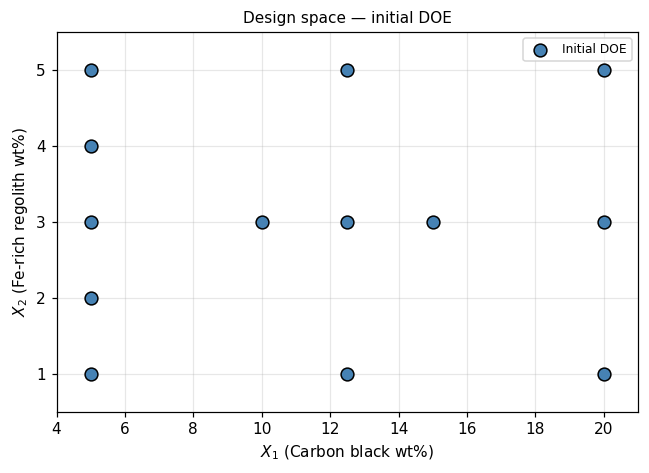

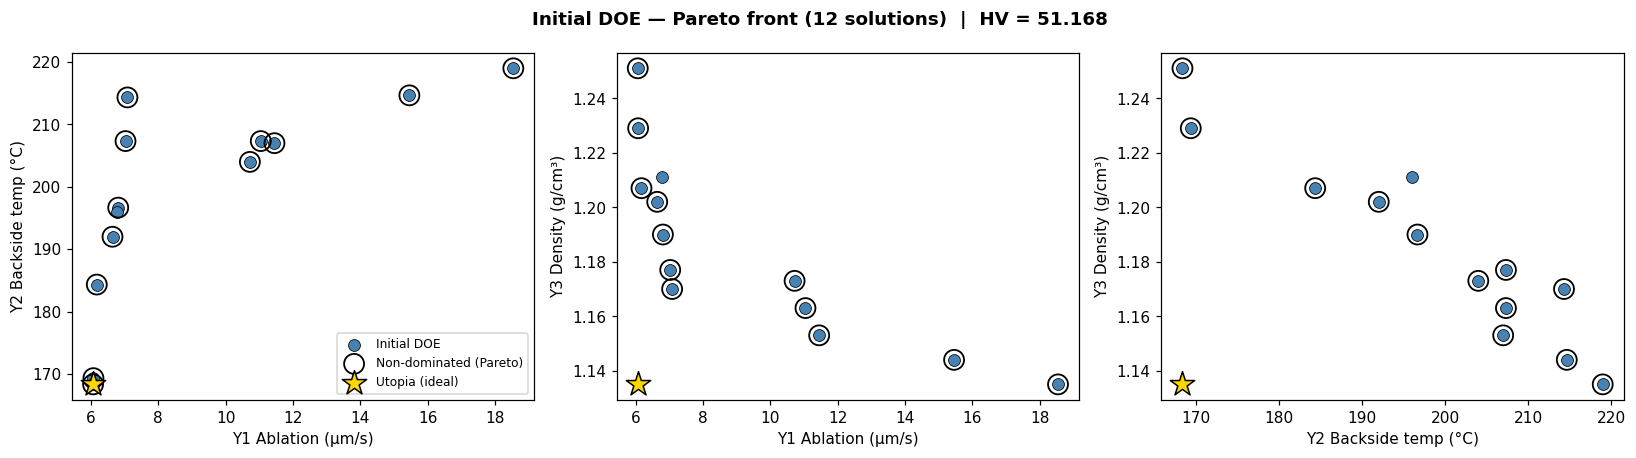

In [4]:
ps0 = camp.baseline()


## 4. Iteration 1 — July 2026

| Date | Event |
|---|---|
| Jul 10 | NU (Rick Tsai) requests **X1 = 19.58, X2 = 1.99** (EHVI 0.785, v1 homoscedastic model) → fabricated as **19.6 / 2.0** (I-369 2 wt%, resin 76.4 wt%) |
| Jul 18 | predicted mean ± σ sent (v1 model, latent 95 % CI) |
| Jul 20 | UIC (Yinong Chen) provides 3 replicates |
| Jul 21 | hypervolume update 51.168 → 53.240 (replicates as points); project handed to Christian Fernandez |

### 4.1 Requested sample and the predictions sent with it
The request is pinned to what was sent. The v4 model is fitted on the same initial DOE and
its own optimizer result is shown for comparison — it differs from the v1 request because
the noise model differs (v1 learned one homoscedastic noise level, v4 uses the measured
s²/n per condition).

#### Iteration 1 · Step 1 — sample requested from UIC

,iteration 1
Trained on,13 conditions (through iteration 0)
Requested X1,19.58
Requested X2,1.99
Fabricated as,19.6 / 2
Resin wt%,76.4
qLogEHVI,0.785
Origin,"v1 model (mobo_analysis.ipynb), sent Jul 10, 2026"
Note,"fabricated as 19.6 / 2.0 (I-369 2 wt%, resin 7..."


v4 optimizer on the same data: X1 = 17.166, X2 = 1.180 (qLogEHVI 0.7696) → differs from the requested sample (max |Δ| = 2.41)


,Objective,R² (train),RMSE (train)
0,Y1 Ablation (µm/s),0.9986,0.1462
1,Y2 Backside temp (°C),0.9803,2.2057
2,Y3 Density (g/cm³),0.9998,0.0005


**v4 model prediction at the requested sample (X1 = 19.580, X2 = 1.990)**

,Objective,mean,sd_latent,95% CI (latent mean),sd_pred,95% PI (one replicate)
0,Y1 Ablation (µm/s),5.9757,0.8626,"[4.2851, 7.6664]",1.0854,"[3.8483, 8.1031]"
1,Y2 Backside temp (°C),179.1581,1.8141,"[175.6025, 182.7136]",11.3254,"[156.9602, 201.3559]"
2,Y3 Density (g/cm³),1.2157,0.0007,"[1.2143, 1.2171]",0.0012,"[1.2133, 1.2181]"


**Predictions that were sent with the request** — source: `email Jul 18, 2026 (v1 homoscedastic GP, latent 95% CI) — resources/email.pdf`

,Objective,mean,sd,low,high
0,Linear ablative rate (µm/s),5.968,1.0260,3.9570,7.9790
1,Backside temp. (°C),177.670,1.4340,174.8594,180.4806
2,Density (g/cm³),1.216,0.0008,1.2144,1.2176


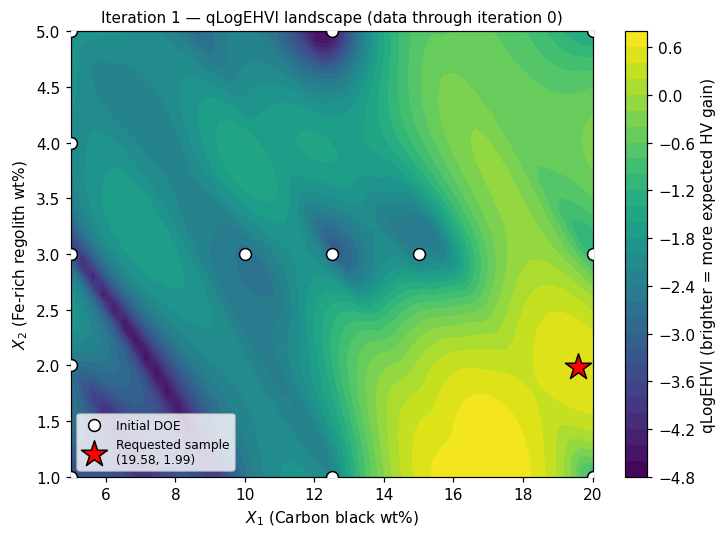

In [5]:
sent1 = sent_from_email(means=[5.968, 177.67, 1.2160], sds=[1.026, 1.434, 0.0008],
                        source='email Jul 18, 2026 (v1 homoscedastic GP, latent 95% CI) — resources/email.pdf')
rec1 = camp.propose(1, pinned={'x': (19.58, 1.99), 'ehvi': 0.785,
                               'origin': 'v1 model (mobo_analysis.ipynb), sent Jul 10, 2026'},
                    sent=sent1, note='fabricated as 19.6 / 2.0 (I-369 2 wt%, resin 76.4 wt%)')


### 4.2 Results provided by UIC (Jul 20, 2026)
The replicates only exist in the email table, so they are typed in and cross-checked
against the spreadsheet rows.

In [6]:
obs1 = results_from_table(19.6, 2.0, y1=[5.65, 5.68, 6.27], y2=[187, 178, 182], y3=[1.216, 1.216, 1.216],
                          source='email Jul 20, 2026 (Yinong Chen) — resources/email.pdf')
camp.import_results(1, obs1)


#### Iteration 1 · Step 2 — results provided by UIC  
source: `email Jul 20, 2026 (Yinong Chen) — resources/email.pdf`

,replicate,X1,X2,Y1,Y2,Y3
0,1,19.6,2.0,5.650000,187.000000,1.216
1,2,19.6,2.0,5.680000,178.000000,1.216
2,3,19.6,2.0,6.270000,182.000000,1.216
mean,—,19.6,2.0,5.866667,182.333333,1.216


Spreadsheet check: (19.6, 2) present with 3 rows → ✓ identical to the imported replicates


### 4.3 Provided vs. received

#### Iteration 1 · Step 3 — provided (predicted) vs. received (observed)

,Objective,Sent µ,Sent 95% range,v4 µ,v4 95% PI,Observed replicates,Obs mean,Δ obs − sent,In sent range,Δ obs − v4,In v4 CI,In v4 PI,z (obs mean)
0,Y1 Ablation (µm/s),5.968,"[3.957, 7.979]",5.9757,"[3.848, 8.103]","5.65, 5.68, 6.27",5.8667,-0.1013,3/3,-0.1091,3/3,3/3,-0.1157
1,Y2 Backside temp (°C),177.670,"[174.9, 180.5]",179.1581,"[157, 201.4]","187, 178, 182",182.3333,4.6633,1/3,3.1753,2/3,3/3,0.4736
2,Y3 Density (g/cm³),1.216,"[1.214, 1.218]",1.2157,"[1.213, 1.218]","1.216, 1.216, 1.216",1.2160,0.0000,3/3,0.0003,3/3,3/3,0.3324


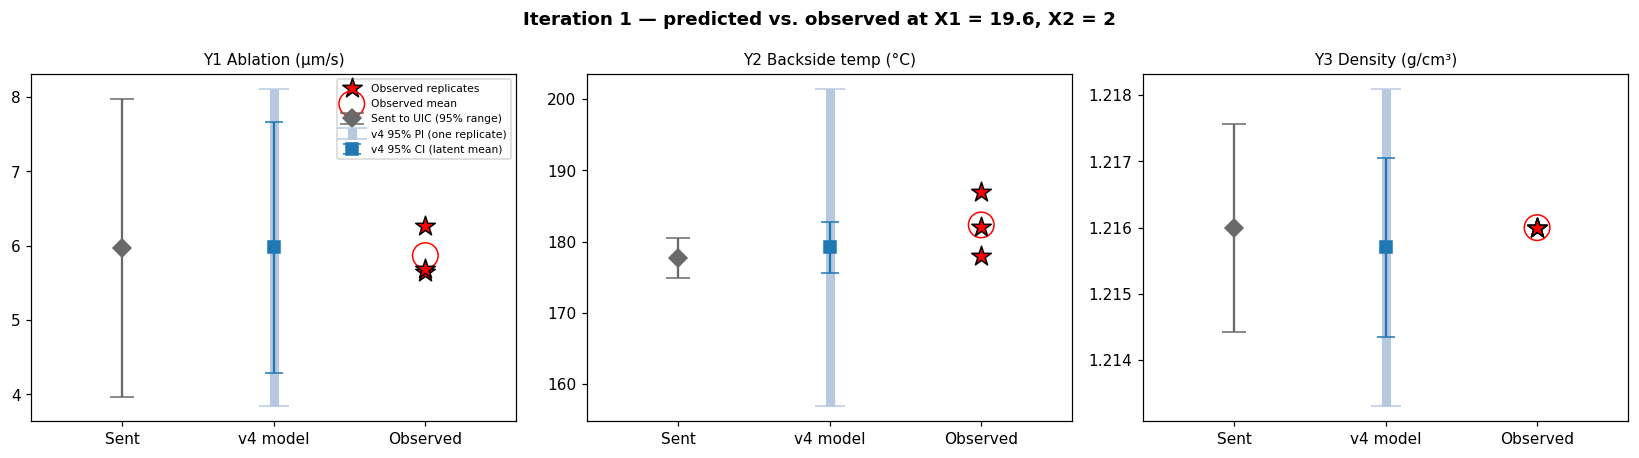

In [7]:
cmp1 = camp.compare(1)


### 4.4 Updated Pareto front and hypervolume

#### Iteration 1 · Step 4 — updated dataset, Pareto front & hypervolume

,Conditions,Pareto size,HV (means),HV (reps),Pareto size (reps)
through iteration 0,13,12,51.1684,51.1684,12
through iteration 1,14,13,51.9738,53.2403,14


HV gain this iteration: +0.8054 on condition means (+1.57%), +2.0719 with replicates as points
  • Y1 Ablation (µm/s): new sample 5.867 vs best before 6.063 → NEW BEST
  • Y2 Backside temp (°C): new sample 182.3 vs best before 168.3 → not the best
  • Y3 Density (g/cm³): new sample 1.216 vs best before 1.135 → not the best
  • New sample is ON the Pareto front; it dominates 0 previous condition(s)


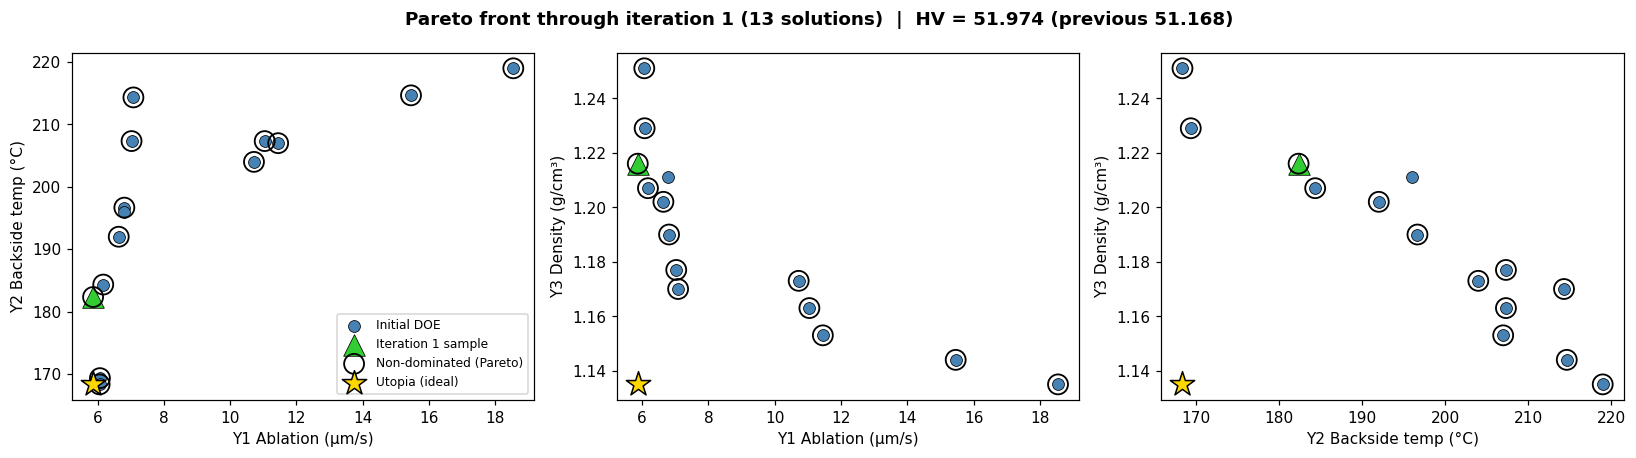


Email (Jul 21, 2026): 51.168 → 53.240, 14 Pareto solutions — the replicates-as-points row above ✓


In [8]:
ps1 = camp.update(1)
print('\nEmail (Jul 21, 2026): 51.168 → 53.240, 14 Pareto solutions — the replicates-as-points row above ✓')


### 4.5 Improvement so far

#### Improvement through iteration 1

,Iteration,Conditions,Best Y1,Best Y2,Best Y3,HV (means),HV (reps),Pareto size,Pareto from BO,Utopia gap,ΔY1 vs DOE %,ΔY2 vs DOE %,ΔY3 vs DOE %,ΔHV vs DOE %
0,0,13,6.0633,168.3333,1.135,51.1684,51.1684,12,0,0.6965,0.0000,0.0,0.0,0.000
1,1,14,5.8667,168.3333,1.135,51.9738,53.2403,13,1,0.6965,-3.2435,0.0,0.0,1.574


**What each tested sample added** (vs. the best condition mean before it)

,Iteration,X1,X2,On Pareto front,Y1 mean,Y1 best before,Y1 improved,Y2 mean,Y2 best before,Y2 improved,Y3 mean,Y3 best before,Y3 improved
0,1,19.6,2.0,True,5.8667,6.0633,True,182.3333,168.3333,False,1.216,1.135,False


Summary:
  • Y1 Ablation (µm/s): best 6.063 → 5.867 (-3.24%)
  • Y2 Backside temp (°C): best 168.3 → 168.3 (+0.00%)
  • Y3 Density (g/cm³): best 1.135 → 1.135 (+0.00%)
  • Hypervolume (means): 51.168 → 51.974 (+1.57%)  |  replicates as points: 51.168 → 53.240
  • Pareto front: 12 → 13 solutions (1 from BO samples)  |  utopia gap 0.696 → 0.696


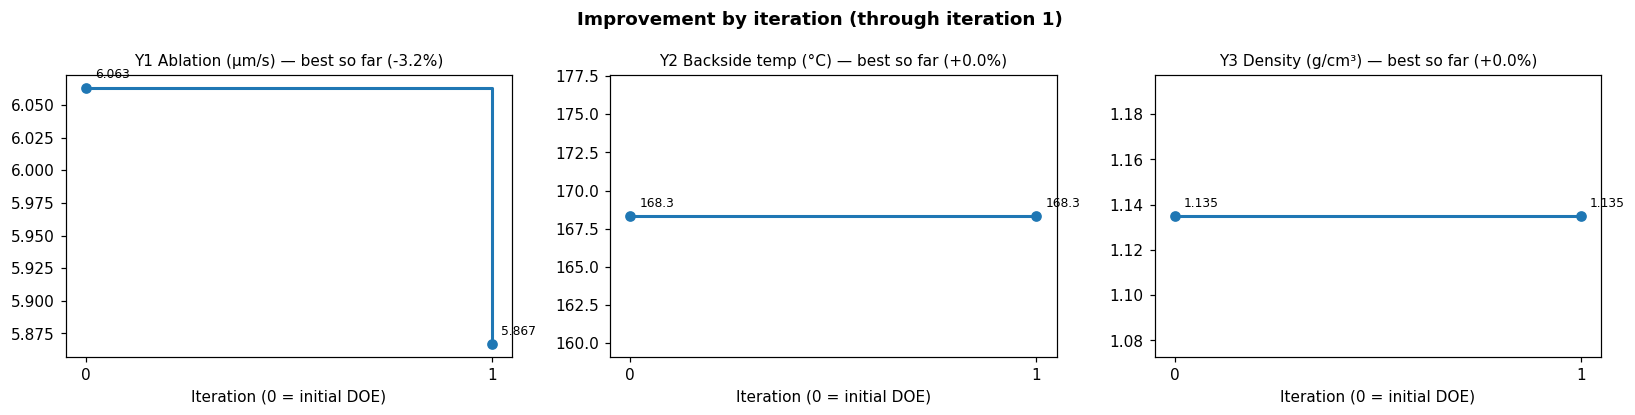

In [9]:
imp1 = camp.improvement(1)


## 5. Iteration 2 — August 2026

| Date | Event |
|---|---|
| Aug 12 | NU (Christian Fernandez) sends `iteration2_recommended_sample.xlsx`: **X1 = 17.352, X2 = 1.000** (qLogEHVI 0.531, v3 replicate-noise model) → **17.4 / 1.0** (I-369 2 wt%, resin 79.6 wt%), with predicted means and 95 % ranges |
| Aug 13 | NU–UIC Zoom meeting |
| Aug 26 | UIC provides 3 replicates (`17.4_1.xlsx`, saved as `data/17.4_1_(08_26).xlsx`) |

### 5.1 Requested sample and the predictions sent with it
Pinned to the record; the sent predictions are read from the workbook that was emailed.
The v4 model is the same as v3, so its optimizer lands at the same place.

Composition sent (wt%): {'Carbon black': 17.4, 'Fe-rich regolith': 1.0, 'I-369': 2.0, 'Resin': 79.6}


#### Iteration 2 · Step 1 — sample requested from UIC

,iteration 2
Trained on,14 conditions (through iteration 1)
Requested X1,17.352
Requested X2,1.0
Fabricated as,17.4 / 1
Resin wt%,79.6
qLogEHVI,0.5311
Origin,"v3 model (mobo_analysis_v3.ipynb), sent Aug 12..."
Note,"fabricated as 17.4 / 1.0 (I-369 2 wt%, resin 7..."


v4 optimizer on the same data: X1 = 17.349, X2 = 1.000 (qLogEHVI 0.5337) → matches the requested sample (max |Δ| = 0.00)


,Objective,R² (train),RMSE (train)
0,Y1 Ablation (µm/s),0.9971,0.2056
1,Y2 Backside temp (°C),0.9714,2.6530
2,Y3 Density (g/cm³),0.9998,0.0005


**v4 model prediction at the requested sample (X1 = 17.352, X2 = 1.000)**

,Objective,mean,sd_latent,95% CI (latent mean),sd_pred,95% PI (one replicate)
0,Y1 Ablation (µm/s),5.6202,1.0584,"[3.5458, 7.6947]",1.2377,"[3.1943, 8.0462]"
1,Y2 Backside temp (°C),194.1952,2.1245,"[190.0311, 198.3592]",11.0460,"[172.5450, 215.8453]"
2,Y3 Density (g/cm³),1.1943,0.0008,"[1.1927, 1.1958]",0.0013,"[1.1918, 1.1968]"


**Predictions that were sent with the request** — source: `../outputs/v3/iteration2_recommended_sample.xlsx`

,Objective,mean,low,high
0,Linear ablative rate (µm/s),5.6200,3.2000,8.1000
1,Backside temp. (°C),194.2000,172.5000,215.8000
2,Density (g/cm³),1.1943,1.1918,1.1968


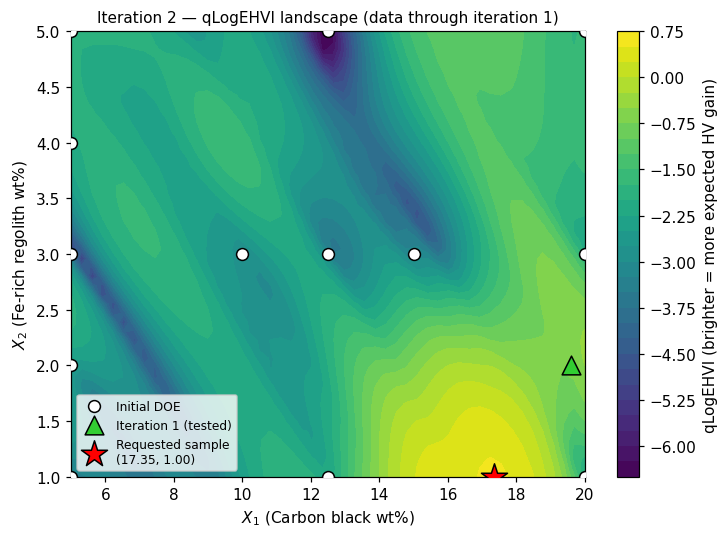

In [10]:
comp2, sent2 = load_sent_recommendation('../outputs/v3/iteration2_recommended_sample.xlsx')
print('Composition sent (wt%):', comp2)
rec2 = camp.propose(2, pinned={'x': (17.352, 1.000), 'ehvi': 0.5311,
                               'origin': 'v3 model (mobo_analysis_v3.ipynb), sent Aug 12, 2026'},
                    sent=sent2, note='fabricated as 17.4 / 1.0 (I-369 2 wt%, resin 79.6 wt%)')


### 5.2 Results provided by UIC (Aug 26, 2026)
Imported directly from UIC's workbook.

In [11]:
obs2 = load_uic_results('../data/17.4_1_(08_26).xlsx', x1=17.4, x2=1.0)
camp.import_results(2, obs2)


#### Iteration 2 · Step 2 — results provided by UIC  
source: `../data/17.4_1_(08_26).xlsx`

,replicate,X1,X2,Y1,Y2,Y3
0,1,17.4,1.0,5.610000,189.000000,1.194
1,2,17.4,1.0,6.020000,202.000000,1.194
2,3,17.4,1.0,6.050000,195.000000,1.194
mean,—,17.4,1.0,5.893333,195.333333,1.194


Spreadsheet check: (17.4, 1) present with 3 rows → ✓ identical to the imported replicates


### 5.3 Provided vs. received

#### Iteration 2 · Step 3 — provided (predicted) vs. received (observed)

,Objective,Sent µ,Sent 95% range,v4 µ,v4 95% PI,Observed replicates,Obs mean,Δ obs − sent,In sent range,Δ obs − v4,In v4 CI,In v4 PI,z (obs mean)
0,Y1 Ablation (µm/s),5.6200,"[3.2, 8.1]",5.6202,"[3.194, 8.046]","5.61, 6.02, 6.05",5.8933,0.2733,3/3,0.2731,3/3,3/3,0.2435
1,Y2 Backside temp (°C),194.2000,"[172.5, 215.8]",194.1952,"[172.5, 215.8]","189, 202, 195",195.3333,1.1333,3/3,1.1382,1/3,3/3,0.1722
2,Y3 Density (g/cm³),1.1943,"[1.192, 1.197]",1.1943,"[1.192, 1.197]","1.194, 1.194, 1.194",1.1940,-0.0003,3/3,-0.0003,3/3,3/3,-0.2790


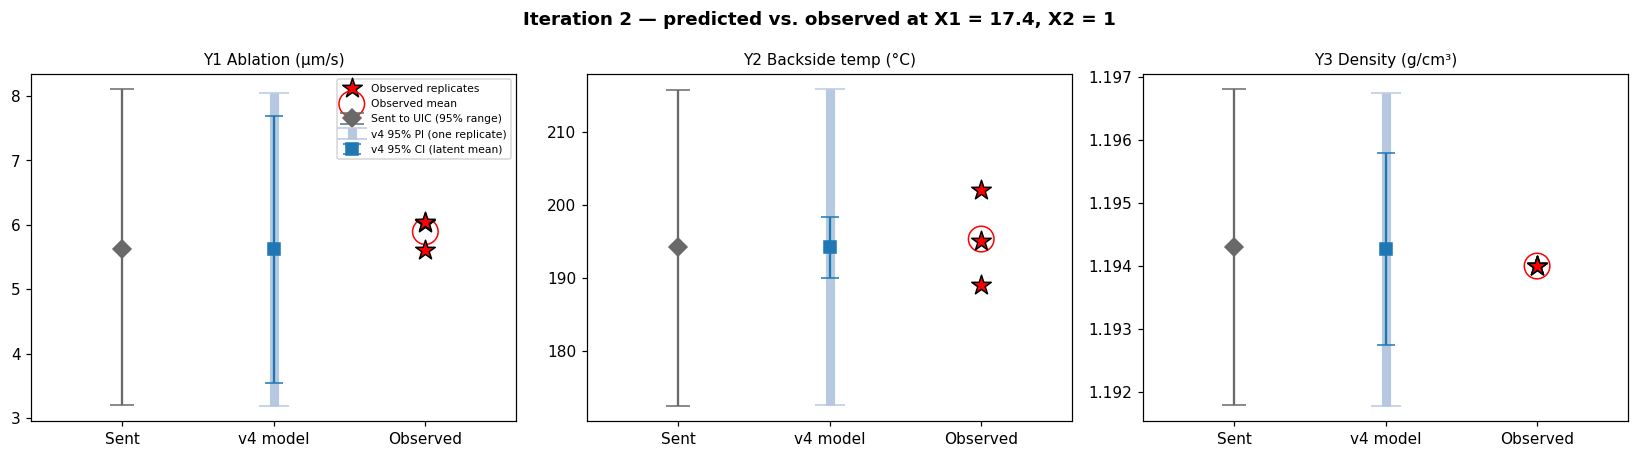

In [12]:
cmp2 = camp.compare(2)


### 5.4 Updated Pareto front and hypervolume

#### Iteration 2 · Step 4 — updated dataset, Pareto front & hypervolume

,Conditions,Pareto size,HV (means),HV (reps),Pareto size (reps)
through iteration 1,14,13,51.9738,53.2403,14
through iteration 2,15,14,52.5026,54.9942,14


HV gain this iteration: +0.5289 on condition means (+1.02%), +1.7538 with replicates as points
  • Y1 Ablation (µm/s): new sample 5.893 vs best before 5.867 → not the best
  • Y2 Backside temp (°C): new sample 195.3 vs best before 168.3 → not the best
  • Y3 Density (g/cm³): new sample 1.194 vs best before 1.135 → not the best
  • New sample is ON the Pareto front; it dominates 1 previous condition(s)


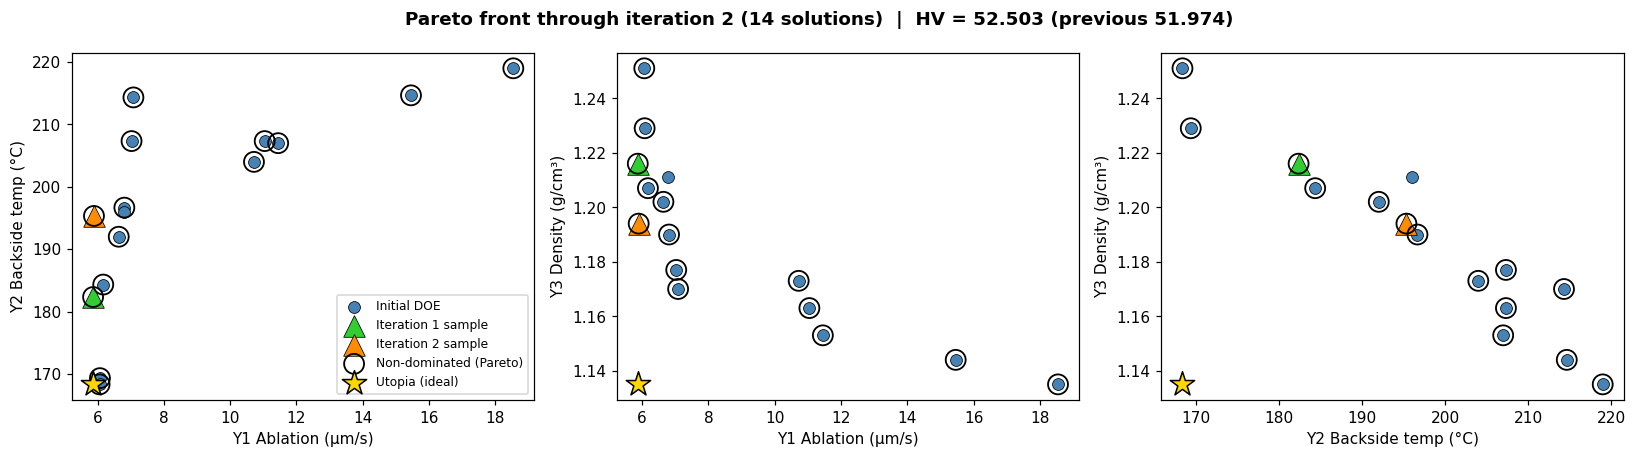

In [13]:
ps2 = camp.update(2)


### 5.5 Improvement so far

#### Improvement through iteration 2

,Iteration,Conditions,Best Y1,Best Y2,Best Y3,HV (means),HV (reps),Pareto size,Pareto from BO,Utopia gap,ΔY1 vs DOE %,ΔY2 vs DOE %,ΔY3 vs DOE %,ΔHV vs DOE %
0,0,13,6.0633,168.3333,1.135,51.1684,51.1684,12,0,0.6965,0.0000,0.0,0.0,0.0000
1,1,14,5.8667,168.3333,1.135,51.9738,53.2403,13,1,0.6965,-3.2435,0.0,0.0,1.5740
2,2,15,5.8667,168.3333,1.135,52.5026,54.9942,14,2,0.6965,-3.2435,0.0,0.0,2.6076


**What each tested sample added** (vs. the best condition mean before it)

,Iteration,X1,X2,On Pareto front,Y1 mean,Y1 best before,Y1 improved,Y2 mean,Y2 best before,Y2 improved,Y3 mean,Y3 best before,Y3 improved
0,1,19.6,2.0,True,5.8667,6.0633,True,182.3333,168.3333,False,1.216,1.135,False
1,2,17.4,1.0,True,5.8933,5.8667,False,195.3333,168.3333,False,1.194,1.135,False


Summary:
  • Y1 Ablation (µm/s): best 6.063 → 5.867 (-3.24%)
  • Y2 Backside temp (°C): best 168.3 → 168.3 (+0.00%)
  • Y3 Density (g/cm³): best 1.135 → 1.135 (+0.00%)
  • Hypervolume (means): 51.168 → 52.503 (+2.61%)  |  replicates as points: 51.168 → 54.994
  • Pareto front: 12 → 14 solutions (2 from BO samples)  |  utopia gap 0.696 → 0.696


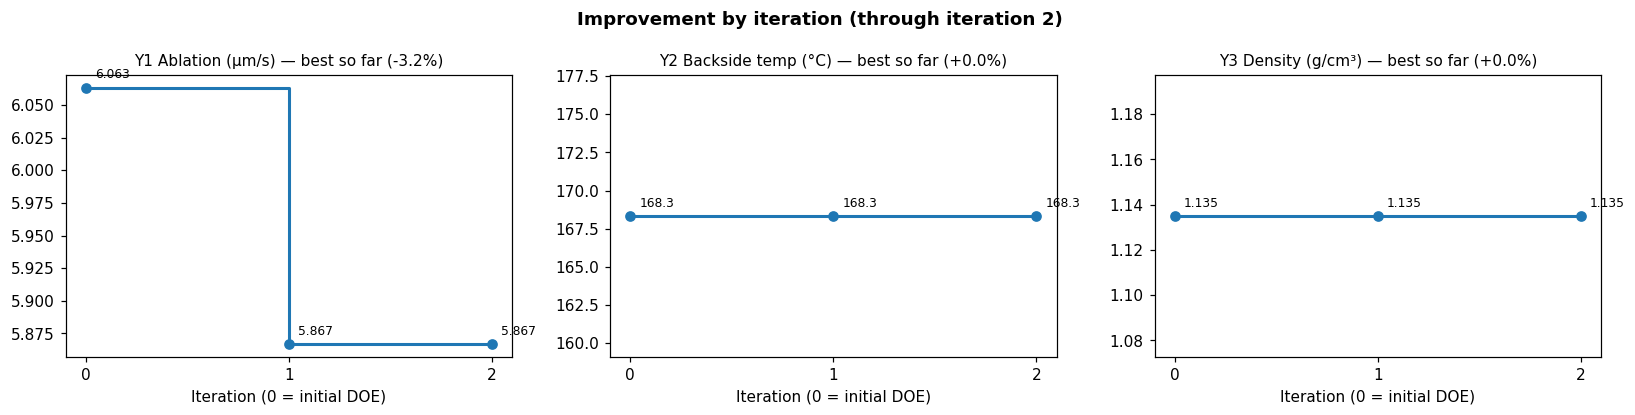

In [14]:
imp2 = camp.improvement(2)


## 6. Should we stop? — probabilistic regret bound, step by step
Reference: J. T. Wilson, *Stopping Bayesian Optimization with Probabilistic Regret Bounds*,
NeurIPS 2024. Following its Algorithm 1, the rule is evaluated **before** the next sample is
requested, on the model fitted to everything through iteration 2.

**The paper's rule.** Stop once the solution is within ε of the optimum with probability at
least 1 − δ under the model. The probability is estimated by Monte Carlo over draws of the
objective from the GP posterior; δ is split into δ_mod (model risk — the estimate must exceed
λ = 1 − δ_mod) and δ_est (estimation risk — a sequential Clopper–Pearson test, Algorithm 2,
keeps drawing until λ is outside the confidence interval). With a planned budget of T
iterations, δ_est is spread over the remaining checks.

**Adaptation to this campaign.** The paper is single-objective and its regret is "the best
value any point could have under the draw, minus the value of our solution under the same
draw". Here the solution is the set of tested formulations, its quality is the hypervolume,
and one formulation is tested per iteration — so the regret is the largest hypervolume gain
**one more formulation** could give under a joint posterior draw (exact on a grid via the box
decomposition of the non-dominated region). The rule reads: *stop when, with probability
≥ 1 − δ under the model, no single further experiment would improve the hypervolume by more
than ε*. The paper's original single-output rule is also applied to each objective.

The five steps below are the five methods `prb_setup → prb_draw → prb_regret → prb_decide →
prb_objectives` (+ `prb_conclusion`); `stopping_check` runs them all in one call.

### 6.1 Step 0 — model and parameters
ε = 1 % of the current hypervolume (a sweep 0.5–10 % is reported), δ = 0.05 = 0.025 + 0.025,
planned budget 10 iterations. The GPs are the same fixed-noise models as for the proposals
(`train_Yvar = s²/n` from the replicates).

In [15]:
st3 = camp.prb_setup(3, eps_frac=0.01, eps_sweep=(0.005, 0.01, 0.02, 0.05, 0.10), delta=0.05, budget=10)


#### Stopping check before iteration 3 · Step 0 — model and parameters

,setting
Model fitted on,data through iteration 2 (15 conditions)
GP noise model,"fixed-noise GPs, train_Yvar = s²/n from the re..."
Solution judged,the Pareto set of the tested formulations
Regret,largest hypervolume gain ONE more formulation ...
Current HV (means),52.502632
Regret bound ε,"1% of HV = 0.525 HV units (sweep: 0.5%, 1%, 2%..."
Risk δ = δ_mod + δ_est,0.05 = 0.025 + 0.025 → λ = 1 − δ_mod = 0.975
δ_est for this check,"0.003125 (budget 10 iterations, 8 checks remai..."


**GP hyperparameters of the model being judged**

,Objective,lengthscale X1 (scaled),lengthscale X2 (scaled),"fixed noise (standardised, mean)"
0,Y1 Ablation (µm/s),0.3524,0.5447,0.0085
1,Y2 Backside temp (°C),0.5559,1.1932,0.1522
2,Y3 Density (g/cm³),1.2466,1.8270,0.0009


### 6.2 Step 1 — draw from the posterior
Joint draws of the three latent objectives on a 40 × 40 grid over the design space plus the
tested conditions (exact sampling: Cholesky of the joint posterior covariance; no
random-feature approximation is needed in 2-D). Each draw is one plausible "truth".

#### Step 1 — 2000 joint posterior draws on a 40×40 grid ∪ 15 tested conditions

Each draw is one plausible version of (Y1, Y2, Y3) over the whole design space, sampled jointly (grid and tested points together) from the GP posterior; the arrays are (2000, 1600, 3) and (2000, 15, 3).


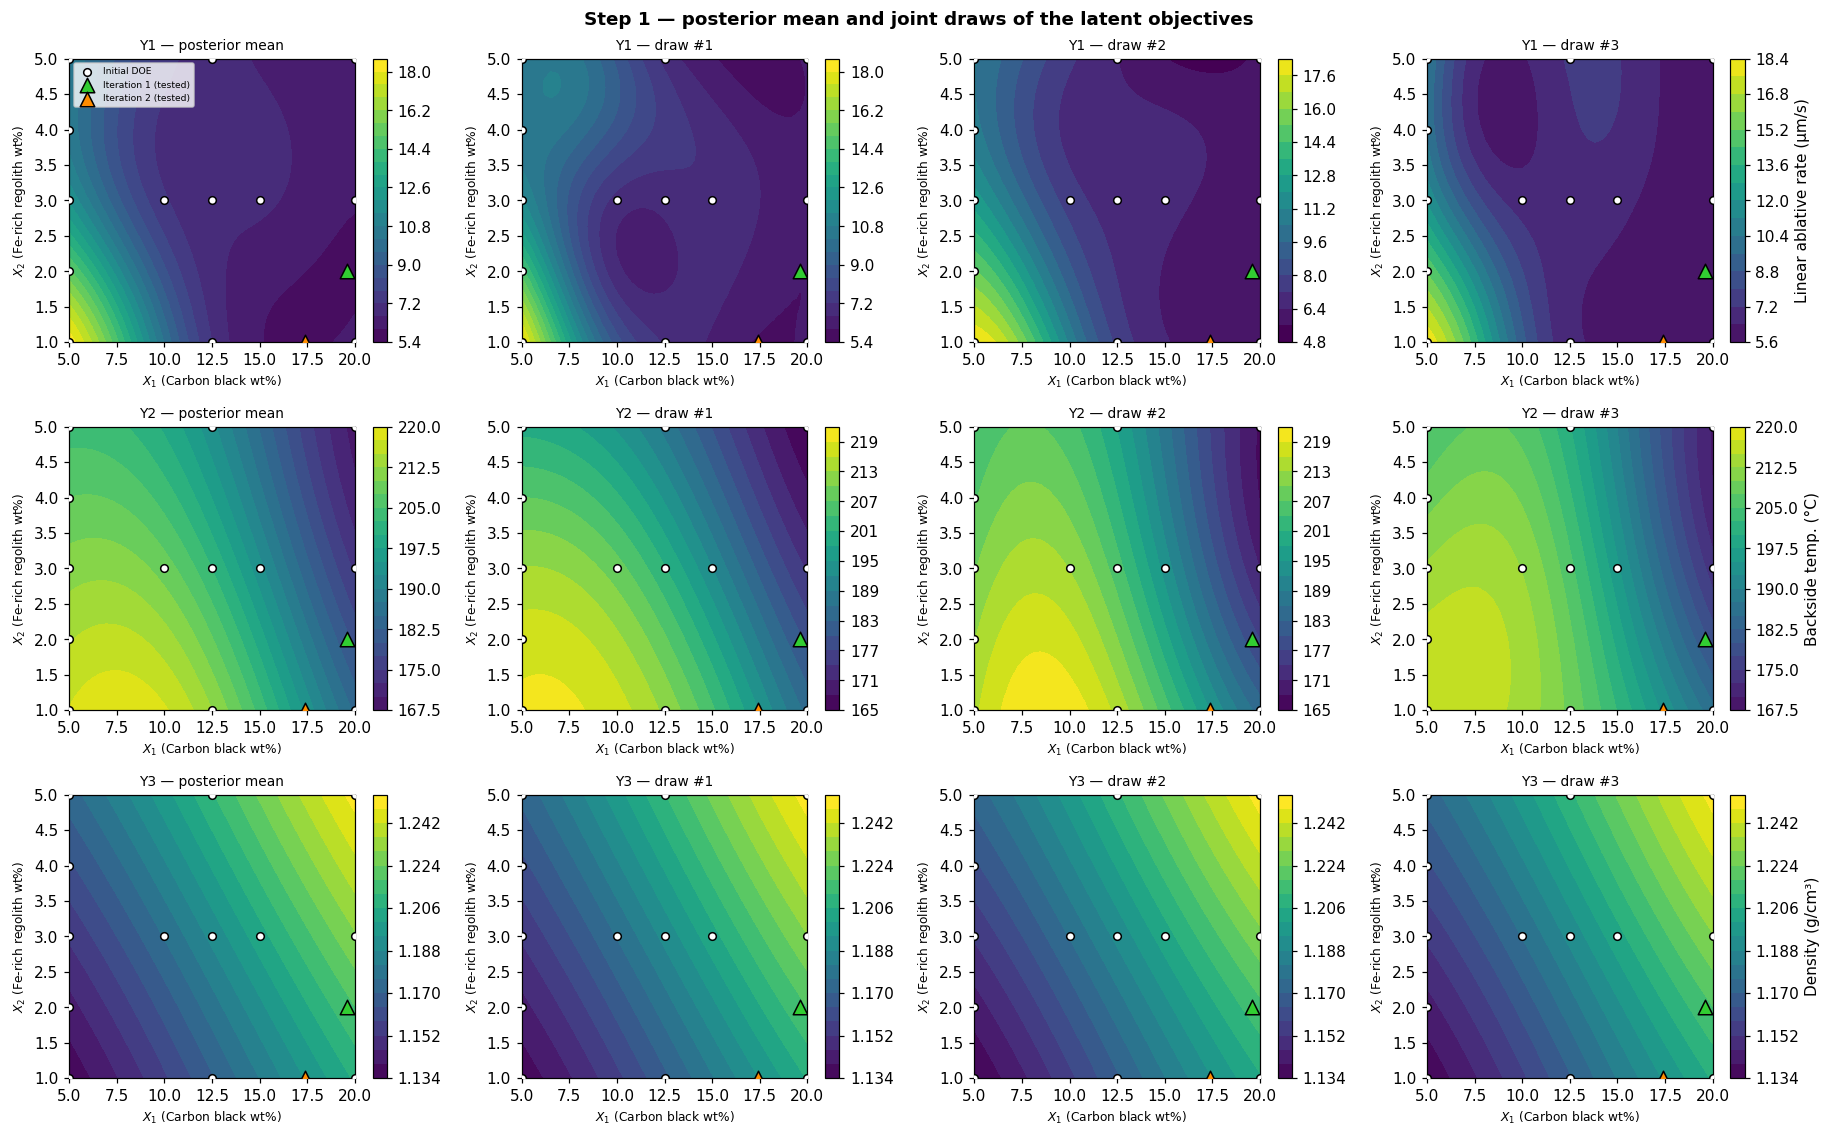

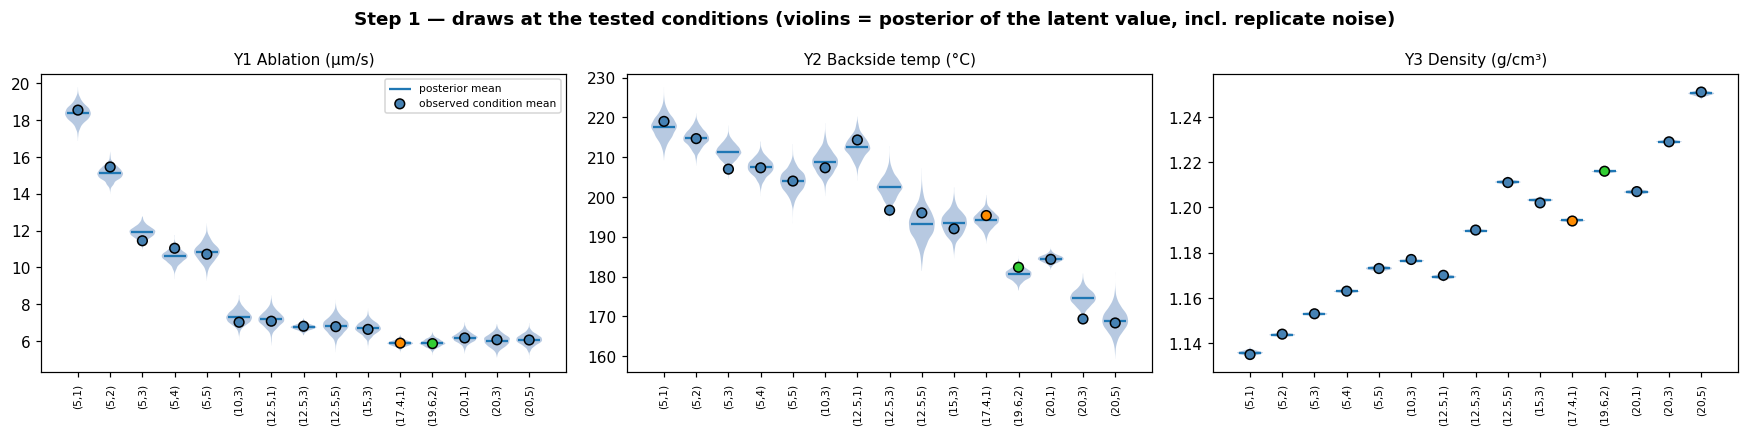

**Sanity check — draws reproduce the posterior at the tested conditions**

,condition,Y1 posterior mean,Y1 mean of draws,Y1 sd of draws,Y2 posterior mean,Y2 mean of draws,Y2 sd of draws,Y3 posterior mean,Y3 mean of draws,Y3 sd of draws
0,"(5, 1)",18.3837,18.3772,0.4263,217.6287,217.6011,2.6553,1.1357,1.1357,0.0008
1,"(5, 2)",15.1092,15.1081,0.3382,214.7952,214.7853,2.0109,1.1437,1.1437,0.0006
2,"(5, 3)",11.9106,11.9074,0.2939,211.2661,211.2600,1.9232,1.1530,1.1530,0.0006
3,"(5, 4)",10.6021,10.6000,0.3244,207.4980,207.4940,2.0101,1.1629,1.1629,0.0006
4,"(5, 5)",10.8237,10.8247,0.4576,203.9179,203.9267,2.5390,1.1731,1.1731,0.0008
5,"(10, 3)",7.2985,7.3074,0.3551,208.7460,208.7479,2.5849,1.1764,1.1764,0.0005
6,"(12.5, 1)",7.1920,7.1947,0.3802,212.5082,212.5697,2.4119,1.1693,1.1693,0.0007
7,"(12.5, 3)",6.7589,6.7640,0.1491,202.4330,202.4211,2.5857,1.1897,1.1897,0.0005
8,"(12.5, 5)",6.8370,6.8452,0.3941,193.1838,193.1634,3.6885,1.2112,1.2112,0.0008
9,"(15, 3)",6.7051,6.7073,0.3047,193.3546,193.3352,2.5971,1.2033,1.2033,0.0005


In [16]:
paths3 = camp.prb_draw(3, n_draws=2000, grid_n=40, n_show=3)


### 6.3 Step 2 — the regret under each draw
For each draw: hypervolume of the tested set *under that draw*, then the best single extra
point on the grid and its hypervolume improvement. The worked examples show a median-regret
and a maximum-regret draw; the histogram is the distribution over all draws, with the ε
thresholds and the gains actually observed in iterations 1 and 2 for reference; the map
shows where the best additional point falls.

#### Step 2 — one-step hypervolume regret under each of the 2000 draws

For draw f: take the tested formulations at their values under f, compute the hypervolume of their Pareto
front, then add every grid point x alone and keep the largest hypervolume improvement. That maximum is the
regret of the current tested set under f — how much ONE more experiment could still gain if f were the truth.


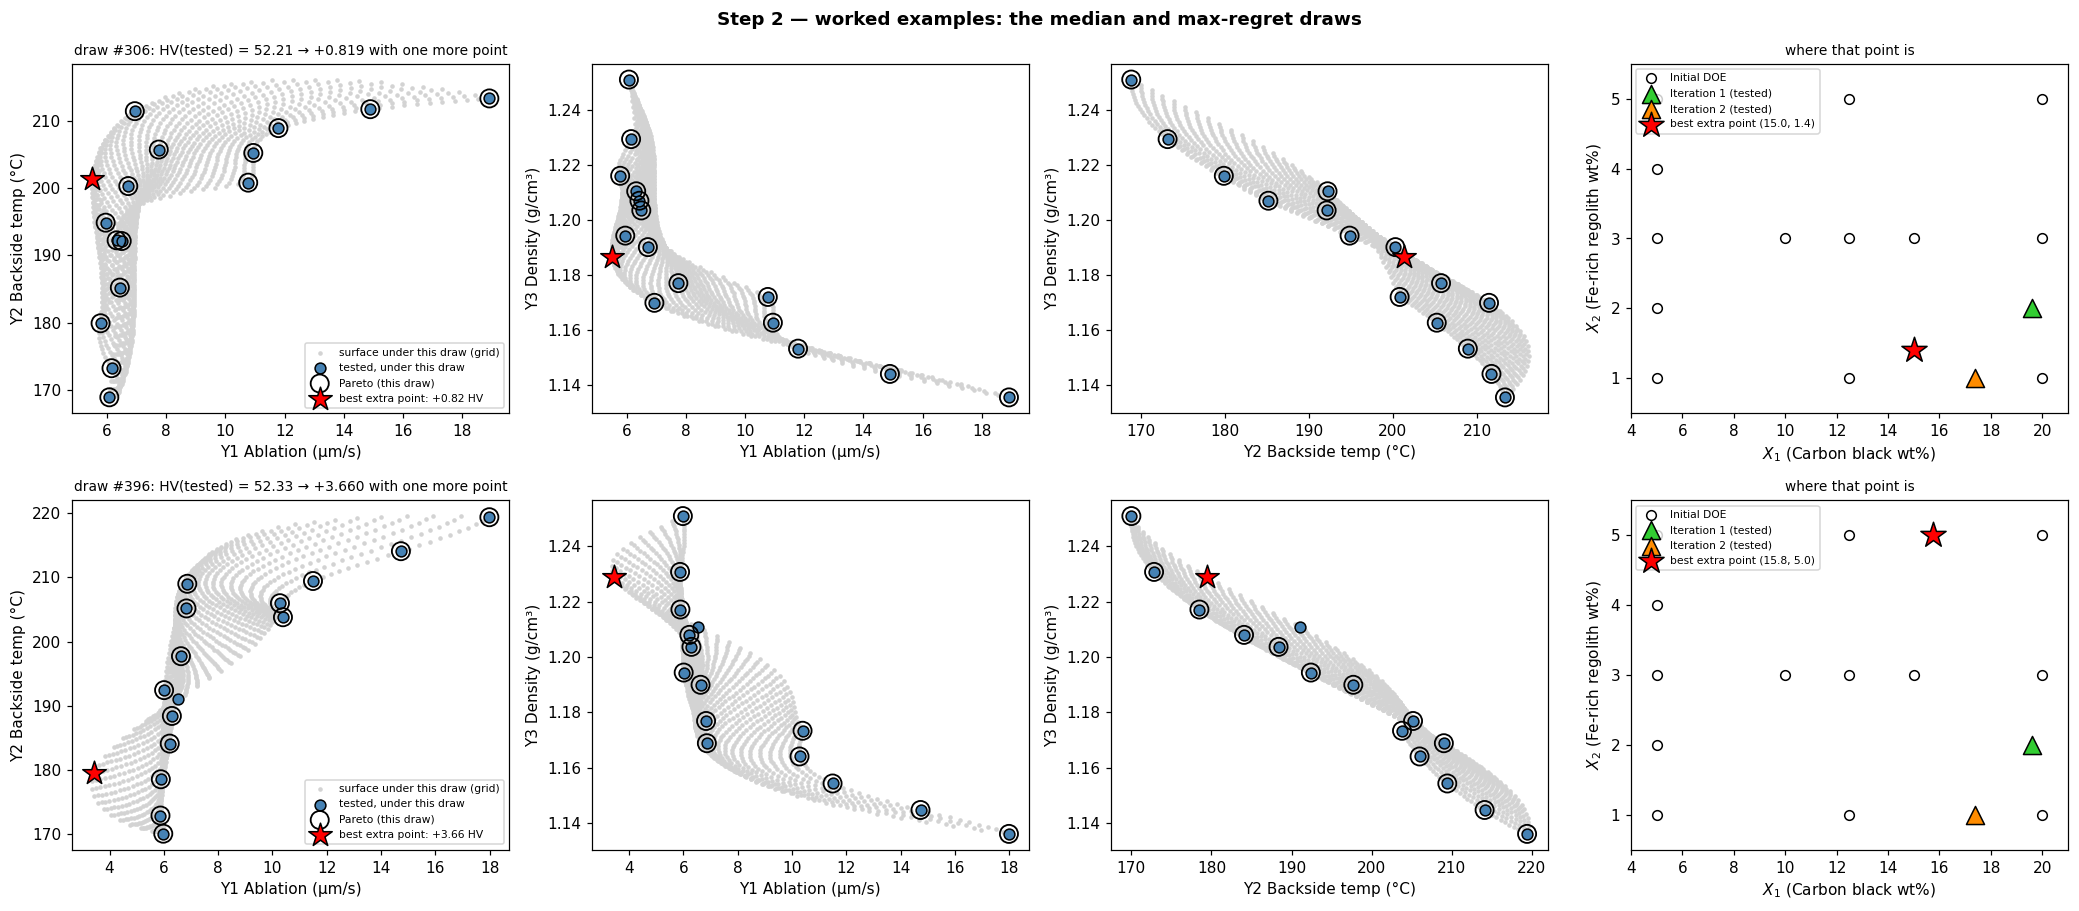

,statistic,one-step HV regret (HV units),as % of current HV
0,mean,0.9354,1.7817
1,median,0.8190,1.5598
2,5th pct,0.4963,0.9454
3,95th pct,1.8085,3.4445
4,max,3.6598,6.9707


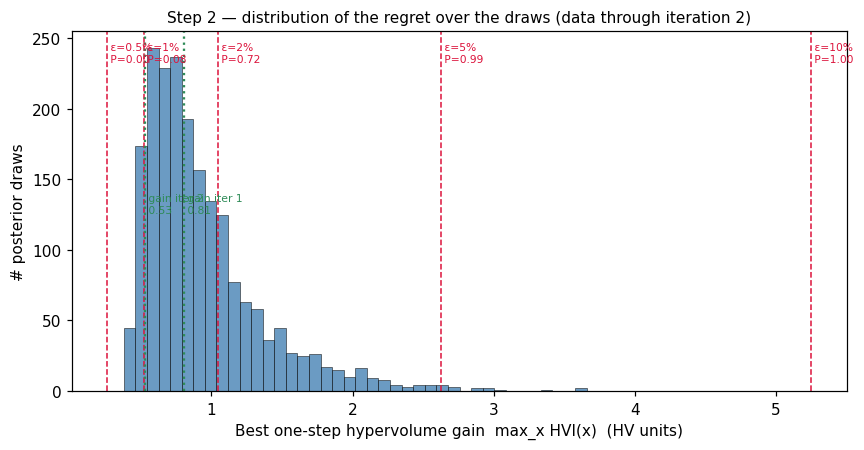

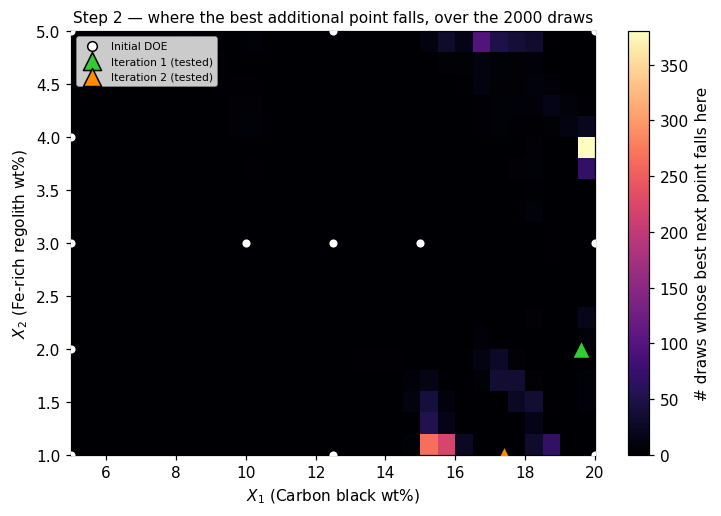

Whole-front context: the model expects the complete Pareto front to reach HV ≈ 57.10; the tested set holds 91.9% of it. (A continuous front is never fully covered by finitely many points, so this is context, not a stopping criterion.)


In [17]:
reg3 = camp.prb_regret(3, examples=('median', 'max'))


### 6.4 Step 3 — the decision, over ε, δ and budget
(a) the sequential test for every ε of the sweep, (b) the test round by round for the
headline ε, (c) how the decision changes with δ, (d) with the planned budget, and the full
curve P(regret ≤ ε) vs ε against λ for several δ.

#### Step 3 — decision: is P(regret ≤ ε) ≥ λ = 1 − δ_mod = 0.975?

**(a) ε sweep** — the sequential test draws in batches of 64, 96, 144, … and stops as soon as λ is outside the Clopper–Pearson interval; STOP needs the whole interval above λ, CONTINUE the whole interval below

,ε (% of HV),ε (HV units),P̂(regret ≤ ε),CI low,CI high,draws used,decision
0,0.5,0.2625,0.0000,0.0000,0.1293,64,CONTINUE
1,1.0,0.5250,0.0938,0.0123,0.2895,64,CONTINUE
2,2.0,1.0501,0.7031,0.4706,0.8789,64,CONTINUE
3,5.0,2.6251,0.9933,0.9804,0.9987,1641,STOP
4,10.0,5.2503,1.0000,0.9780,1.0000,486,STOP


**(b) The test round by round for the headline ε = 1% of HV**

,round j,draws n_j,successes k,level d_j,estimate,CI low,CI high,outcome
0,1,64,6,0.00028,0.09375,0.01232,0.28951,decided: continue


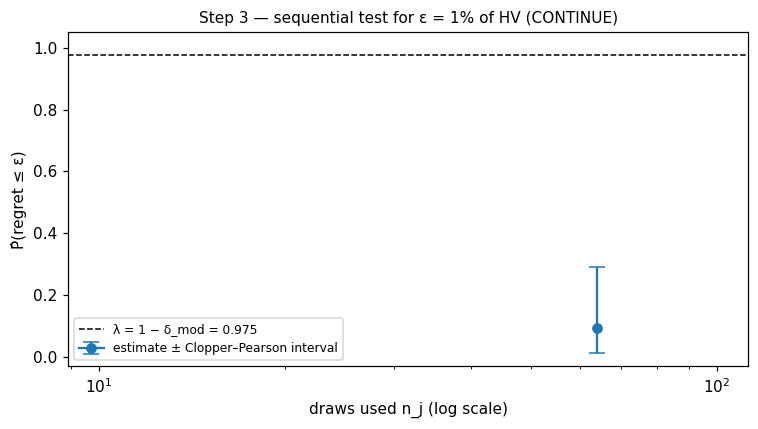

**(c) Sensitivity to the risk δ** (rows) for each ε (columns) — the estimate is the same, only λ and the interval width change

,λ = 1 − δ/2,ε = 0.5% HV,ε = 1% HV,ε = 2% HV,ε = 5% HV,ε = 10% HV
δ,,,,,,
0.01,0.995,CONTINUE,CONTINUE,CONTINUE,UNDECIDED,UNDECIDED
0.05,0.975,CONTINUE,CONTINUE,CONTINUE,STOP,STOP
0.10,0.950,CONTINUE,CONTINUE,CONTINUE,STOP,STOP


**(d) Sensitivity to the planned budget T** for ε = 1% (δ_est^t = δ_est / (T − 2))

,remaining checks,δ_est^t,P̂,CI low,CI high,draws used,decision
budget T,,,,,,,
5,3,0.0083,0.0938,0.0148,0.2734,64,CONTINUE
10,8,0.0031,0.0938,0.0123,0.2895,64,CONTINUE
20,18,0.0014,0.0938,0.0106,0.3023,64,CONTINUE


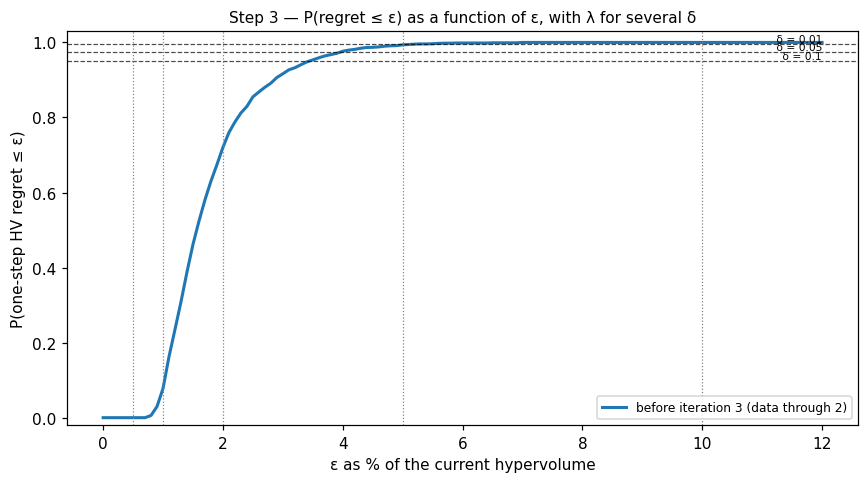

In [18]:
tab3 = camp.prb_decide(3, deltas=(0.01, 0.05, 0.10), budgets=(5, 10, 20))


### 6.5 Step 4 — the paper's single-objective rule, per output
Is the best tested condition for each output already within ε_k of that output's optimum
(ε_k = 5 % of the output's DOE range)?

In [19]:
obj3 = camp.prb_objectives(3)


#### Step 4 — per-objective diagnostic (the paper's single-output rule; ε_k = 5% of the DOE range, δ_est split over 3 tests)

,Objective,"best tested (X1, X2)",posterior mean there,ε_k,median regret,P̂(regret ≤ ε_k),CI low,CI high,draws used,decision
0,Y1 Ablation (µm/s),"(17.4, 1)",5.8866,0.6240,0.4149,0.75,0.5031,0.9176,64,CONTINUE
1,Y2 Backside temp (°C),"(20, 5)",168.9295,2.5333,0.0000,1.00,0.9758,1.0000,486,STOP
2,Y3 Density (g/cm³),"(5, 1)",1.1357,0.0058,0.0000,1.00,0.9758,1.0000,486,STOP


### 6.6 Conclusion — should we stop?

In [20]:
decision3 = camp.prb_conclusion(3)


CONCLUSION (stopping check before iteration 3, data through iteration 2, 2000 draws)
  ε = 1% of HV (0.525 units), δ = 0.05: P̂(regret ≤ ε) = 0.094 vs λ = 0.975  →  CONTINUE — the model still expects at least one formulation that would improve the hypervolume by more than ε.
  Expected best gain from one more experiment: 0.935 HV units (1.78% of HV); observed gains of the tested iterations: 0.805, 0.529
  The rule would say STOP for ε ≥ 5% of HV (2.63 units)
  Whole-front coverage: 91.9% of the hypervolume the model believes attainable
  Per objective: optimum already found for Y2 Backside temp (°C), Y3 Density (g/cm³); not yet for Y1 Ablation (µm/s)
  Caveat (paper §5.3): the verdict is only as good as the model — it uses the same replicate-noise GPs that make the proposals.


### 6.7 How the rule evolved over the campaign
The same check as it would have been made before each request — model on the data through
iterations 0, 1 and 2, same draws/parameters — so the probability that no further formulation
is worth more than ε can be followed stage by stage.

**P̂(one-step HV regret ≤ ε) before each request**

ε (% of HV),ε = 1% HV,ε = 2% HV,ε = 5% HV,ε = 10% HV
Check before iteration,,,,
1,0.000,0.000,0.391,0.781
2,0.000,0.156,0.562,0.945
3,0.094,0.703,0.993,1.000


**Decision before each request**

ε (% of HV),ε = 1% HV,ε = 2% HV,ε = 5% HV,ε = 10% HV
Check before iteration,,,,
1,CONTINUE,CONTINUE,CONTINUE,CONTINUE
2,CONTINUE,CONTINUE,CONTINUE,CONTINUE
3,CONTINUE,CONTINUE,STOP,STOP


**Expected gain of one more experiment and front coverage, stage by stage**

,Data through,Conditions,HV (means),E[max HVI],median regret,E[HV*],front coverage
Check before iteration,,,,,,,
1,0,13,51.1684,3.4861,3.2161,61.0595,0.8380
2,1,14,51.9738,2.5682,2.2107,58.6392,0.8863
3,2,15,52.5026,0.9354,0.8190,57.1038,0.9194


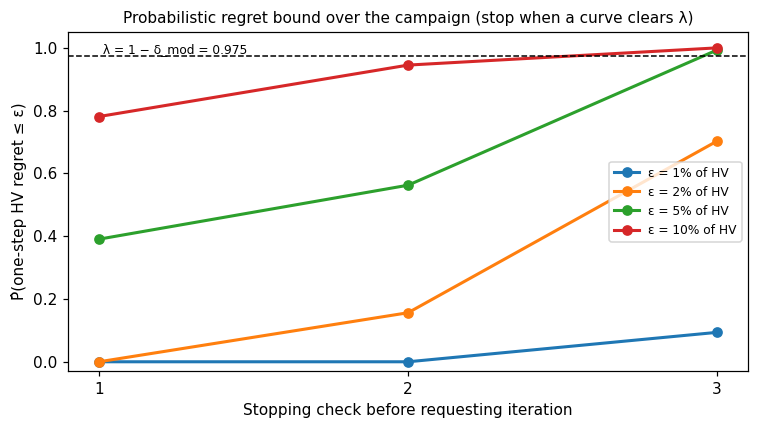

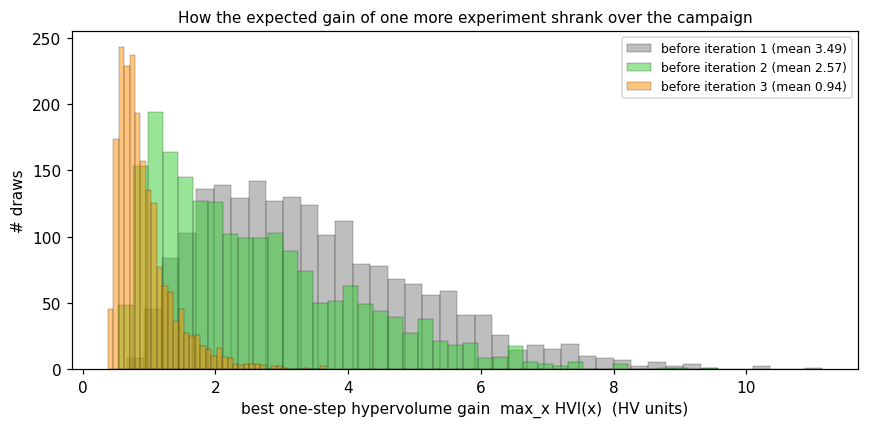

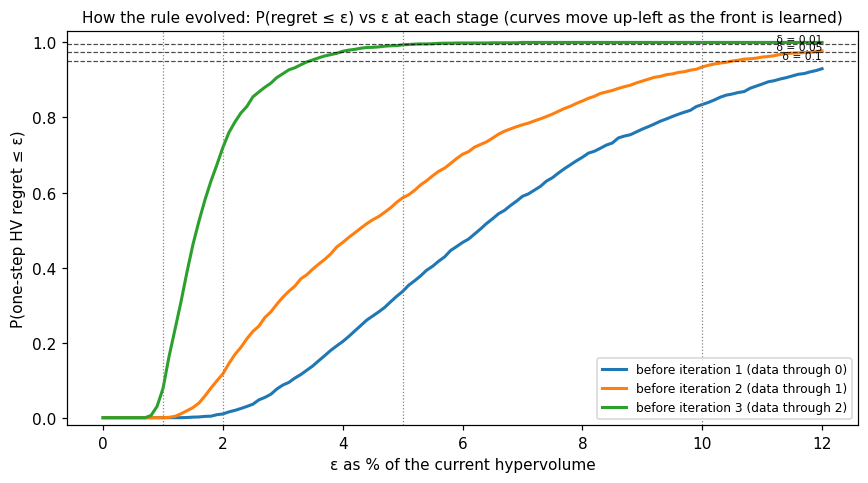

In [21]:
traj = camp.stopping_trajectory(3, eps_sweep=(0.01, 0.02, 0.05, 0.10), deltas=(0.01, 0.05, 0.10))


### 6.8 The one figure to share
Two panels, no statistics vocabulary. Left: how much the model expects one more experiment
to improve the Pareto front (as a share of the current hypervolume), next to what each
experiment actually delivered — the room for improvement is shrinking. Right: the
probability that no further experiment is worth more than a given tolerance; the campaign
can stop once a line is above the dashed 97.5 % confidence level. Saved to
`../outputs/v4/share/stopping_summary.png`.

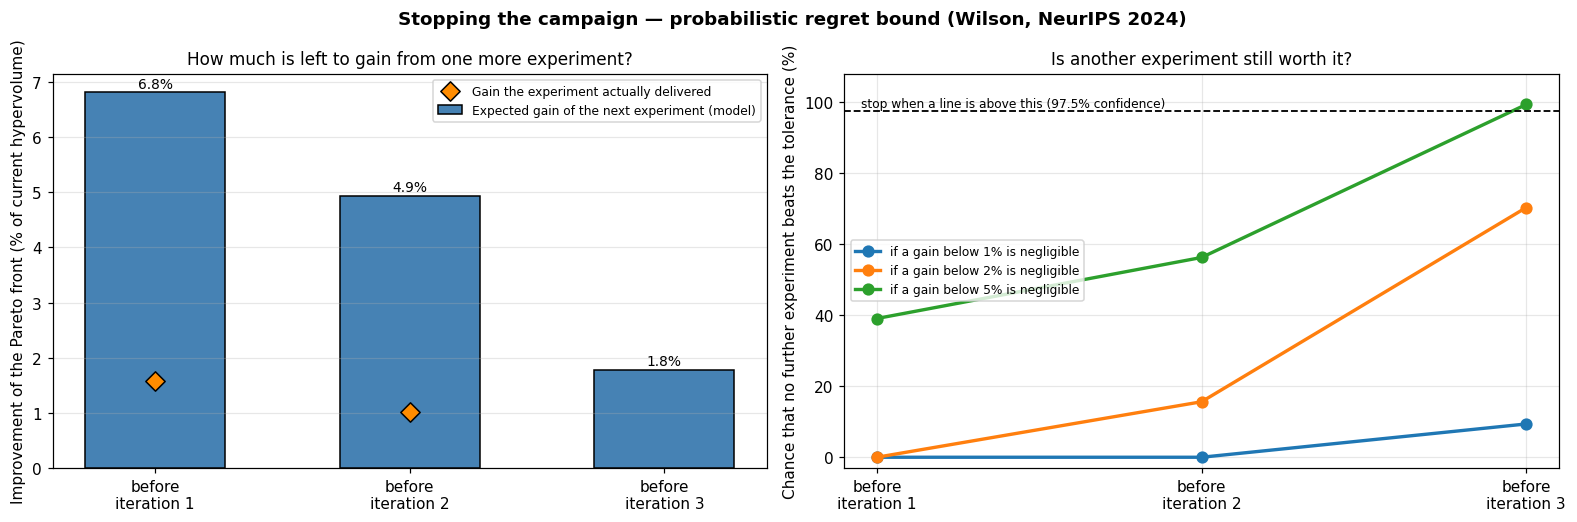

In [22]:
camp.stopping_summary_figure(traj, path='../outputs/v4/share/stopping_summary.png')


## 7. Iteration 3 — requested sample (if the campaign continues)
### 7.1 Requested sample
Fitted on everything through iteration 2 (15 conditions); nothing is pinned, so the
optimizer result *is* the proposal. The recommendation workbook for UIC is written in
Section 9. **When the sample is sent**, pin it here
(`pinned={'x': (X1, X2), 'ehvi': …, 'origin': 'v4 model, sent <date>'}`) so later re-runs keep
the record fixed.

#### Iteration 3 · Step 1 — sample requested from UIC

,iteration 3
Trained on,15 conditions (through iteration 2)
Requested X1,20.0
Requested X2,2.155868
Fabricated as,20 / 2.2
Resin wt%,75.8
qLogEHVI,-0.441303
Origin,"v4 optimizer (this run, seed 42)"
Note,to be sent to UIC — recommendation file writte...


v4 optimizer on the same data: X1 = 20.000, X2 = 2.156 (qLogEHVI -0.4413)


,Objective,R² (train),RMSE (train)
0,Y1 Ablation (µm/s),0.9969,0.2101
1,Y2 Backside temp (°C),0.9710,2.5825
2,Y3 Density (g/cm³),0.9998,0.0005


**v4 model prediction at the requested sample (X1 = 20.000, X2 = 2.156)**

,Objective,mean,sd_latent,95% CI (latent mean),sd_pred,95% PI (one replicate)
0,Y1 Ablation (µm/s),5.9180,0.2087,"[5.5089, 6.3271]",0.6572,"[4.6298, 7.2061]"
1,Y2 Backside temp (°C),178.4370,1.4420,"[175.6108, 181.2632]",10.7036,"[157.4578, 199.4161]"
2,Y3 Density (g/cm³),1.2195,0.0006,"[1.2183, 1.2207]",0.0012,"[1.2172, 1.2218]"


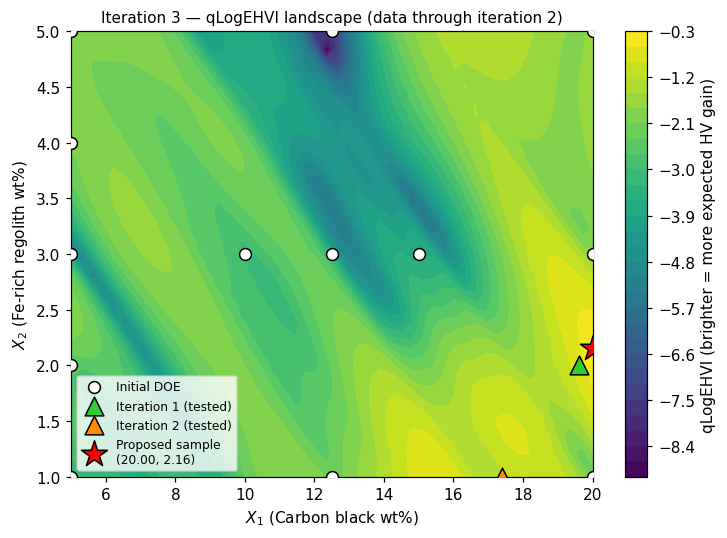

In [23]:
rec3 = camp.propose(3, note='to be sent to UIC — recommendation file written in Section 9')


### 7.2 Results provided by UIC — *pending*
When they arrive, save UIC's workbook under `../data/` and run the same steps:

```python
obs3 = load_uic_results('../data/<uic file>.xlsx', x1=<X1 fabricated>, x2=<X2 fabricated>)
camp.import_results(3, obs3)
cmp3 = camp.compare(3)
ps3  = camp.update(3)
imp3 = camp.improvement(3)
```
then append the replicate rows to `../data/ablation_data.xlsx`, add the condition to
`ITERATION_SAMPLES` (Section 0), and add a stopping check `camp.stopping_check(4)` (or the
step-by-step calls of Section 6) before `camp.propose(4)`.

## 8. Campaign progress
### 8.1 Requested vs. provided — how the model performed
One row per iteration and objective: the formulation we requested, the prediction and
expected range that were **sent** to UIC, what UIC **measured**, the error, and whether the
measurements fell inside the range we gave them. (Iteration 1's range was the v1 model's
interval of the *mean*, which is why the backside-temperature replicates fell outside it;
from iteration 2 on, the range sent is the replicate-noise model's range *per replicate*.)
Exported by Section 9 to `../outputs/v4/share/model_performance.xlsx` and `.png`.

,Iteration,Formulation (CB/regolith wt%),Objective,Predicted (sent),Expected range (sent),Measured replicates,Measured mean,Error (% of predicted),Replicates inside range,Verdict
0,1,19.6 / 2,Linear ablative rate (µm/s),5.968,3.957 – 7.979,"5.65, 5.68, 6.27",5.867,1.7%,3 of 3,✓ all replicates inside the range
1,1,19.6 / 2,Backside temp. (°C),177.7,174.9 – 180.5,"187, 178, 182",182.3,2.6%,1 of 3,✗ mean outside the sent range
2,1,19.6 / 2,Density (g/cm³),1.216,1.214 – 1.218,"1.216, 1.216, 1.216",1.216,0.0%,3 of 3,✓ all replicates inside the range
3,2,17.4 / 1,Linear ablative rate (µm/s),5.62,3.2 – 8.1,"5.61, 6.02, 6.05",5.893,4.9%,3 of 3,✓ all replicates inside the range
4,2,17.4 / 1,Backside temp. (°C),194.2,172.5 – 215.8,"189, 202, 195",195.3,0.6%,3 of 3,✓ all replicates inside the range
5,2,17.4 / 1,Density (g/cm³),1.194,1.192 – 1.197,"1.194, 1.194, 1.194",1.194,0.0%,3 of 3,✓ all replicates inside the range


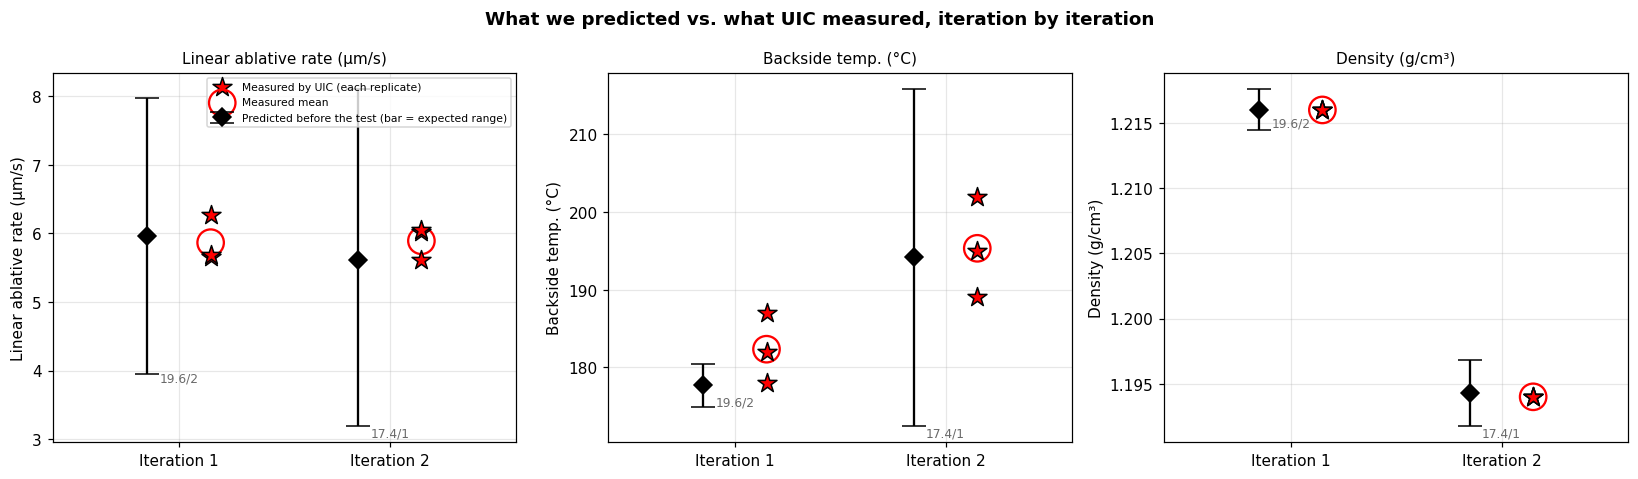

In [24]:
perf = camp.performance_table(compact=True)
display(perf)
camp.performance_figure(path='../outputs/v4/share/model_performance.png')


Full technical table (v4-model means alongside the sent values, hypervolume after each iteration):

In [25]:
camp.table().round(4)


,Iteration,Requested X1,Requested X2,Fabricated,qLogEHVI,Status,Y1 sent µ,Y1 v4 µ,Y1 observed,Y2 sent µ,Y2 v4 µ,Y2 observed,Y3 sent µ,Y3 v4 µ,Y3 observed,HV after (means),HV after (reps),Origin
0,1,19.580,1.9900,19.6 / 2,0.7850,tested,5.968,5.9757,5.8667,177.67,179.1581,182.3333,1.2160,1.2157,1.216,51.9738,53.2403,"v1 model (mobo_analysis.ipynb), sent Jul 10, 2026"
1,2,17.352,1.0000,17.4 / 1,0.5311,tested,5.620,5.6202,5.8933,194.20,194.1952,195.3333,1.1943,1.1943,1.194,52.5026,54.9942,"v3 model (mobo_analysis_v3.ipynb), sent Aug 12..."
2,3,20.000,2.1559,20 / 2.2,-0.4413,pending,NaN,5.9180,NaN,NaN,178.4370,NaN,NaN,1.2195,NaN,NaN,NaN,"v4 optimizer (this run, seed 42)"


### 8.2 Prediction accuracy across iterations
Distance of each observed condition mean from what was sent and from the v4 model (in
units of the model's predictive σ), and how many replicates fell inside the intervals.

,Iteration,Objective,Obs mean,v4 µ,Δ obs − v4 µ,|Δ| / σ_pred (v4),reps in v4 PI,Sent µ,Δ obs − sent µ,reps in sent range
0,1,Y1 Ablation (µm/s),5.8667,5.9757,-0.1091,0.1005,3,5.9680,-0.1013,3
1,1,Y2 Backside temp (°C),182.3333,179.1581,3.1753,0.2804,3,177.6700,4.6633,1
2,1,Y3 Density (g/cm³),1.2160,1.2157,0.0003,0.2464,3,1.2160,0.0000,3
3,2,Y1 Ablation (µm/s),5.8933,5.6202,0.2731,0.2206,3,5.6200,0.2733,3
4,2,Y2 Backside temp (°C),195.3333,194.1952,1.1382,0.1030,3,194.2000,1.1333,3
5,2,Y3 Density (g/cm³),1.1940,1.1943,-0.0003,0.2132,3,1.1943,-0.0003,3


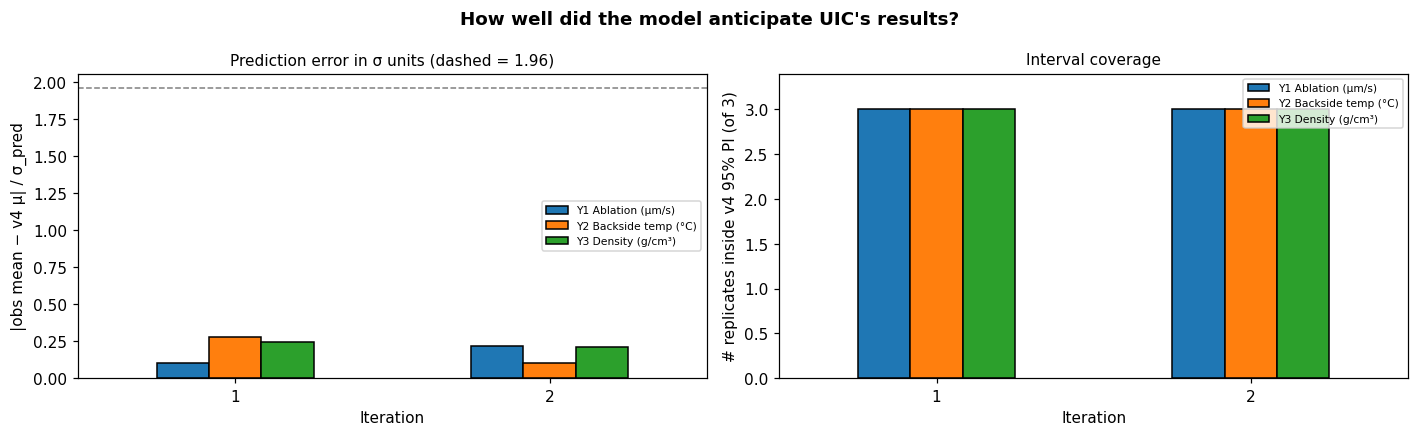

In [26]:
acc = camp.prediction_accuracy()


### 8.3 Improvement dashboard — all tested iterations

#### Improvement through iteration 2

,Iteration,Conditions,Best Y1,Best Y2,Best Y3,HV (means),HV (reps),Pareto size,Pareto from BO,Utopia gap,ΔY1 vs DOE %,ΔY2 vs DOE %,ΔY3 vs DOE %,ΔHV vs DOE %
0,0,13,6.0633,168.3333,1.135,51.1684,51.1684,12,0,0.6965,0.0000,0.0,0.0,0.0000
1,1,14,5.8667,168.3333,1.135,51.9738,53.2403,13,1,0.6965,-3.2435,0.0,0.0,1.5740
2,2,15,5.8667,168.3333,1.135,52.5026,54.9942,14,2,0.6965,-3.2435,0.0,0.0,2.6076


**What each tested sample added** (vs. the best condition mean before it)

,Iteration,X1,X2,On Pareto front,Y1 mean,Y1 best before,Y1 improved,Y2 mean,Y2 best before,Y2 improved,Y3 mean,Y3 best before,Y3 improved
0,1,19.6,2.0,True,5.8667,6.0633,True,182.3333,168.3333,False,1.216,1.135,False
1,2,17.4,1.0,True,5.8933,5.8667,False,195.3333,168.3333,False,1.194,1.135,False


Summary:
  • Y1 Ablation (µm/s): best 6.063 → 5.867 (-3.24%)
  • Y2 Backside temp (°C): best 168.3 → 168.3 (+0.00%)
  • Y3 Density (g/cm³): best 1.135 → 1.135 (+0.00%)
  • Hypervolume (means): 51.168 → 52.503 (+2.61%)  |  replicates as points: 51.168 → 54.994
  • Pareto front: 12 → 14 solutions (2 from BO samples)  |  utopia gap 0.696 → 0.696


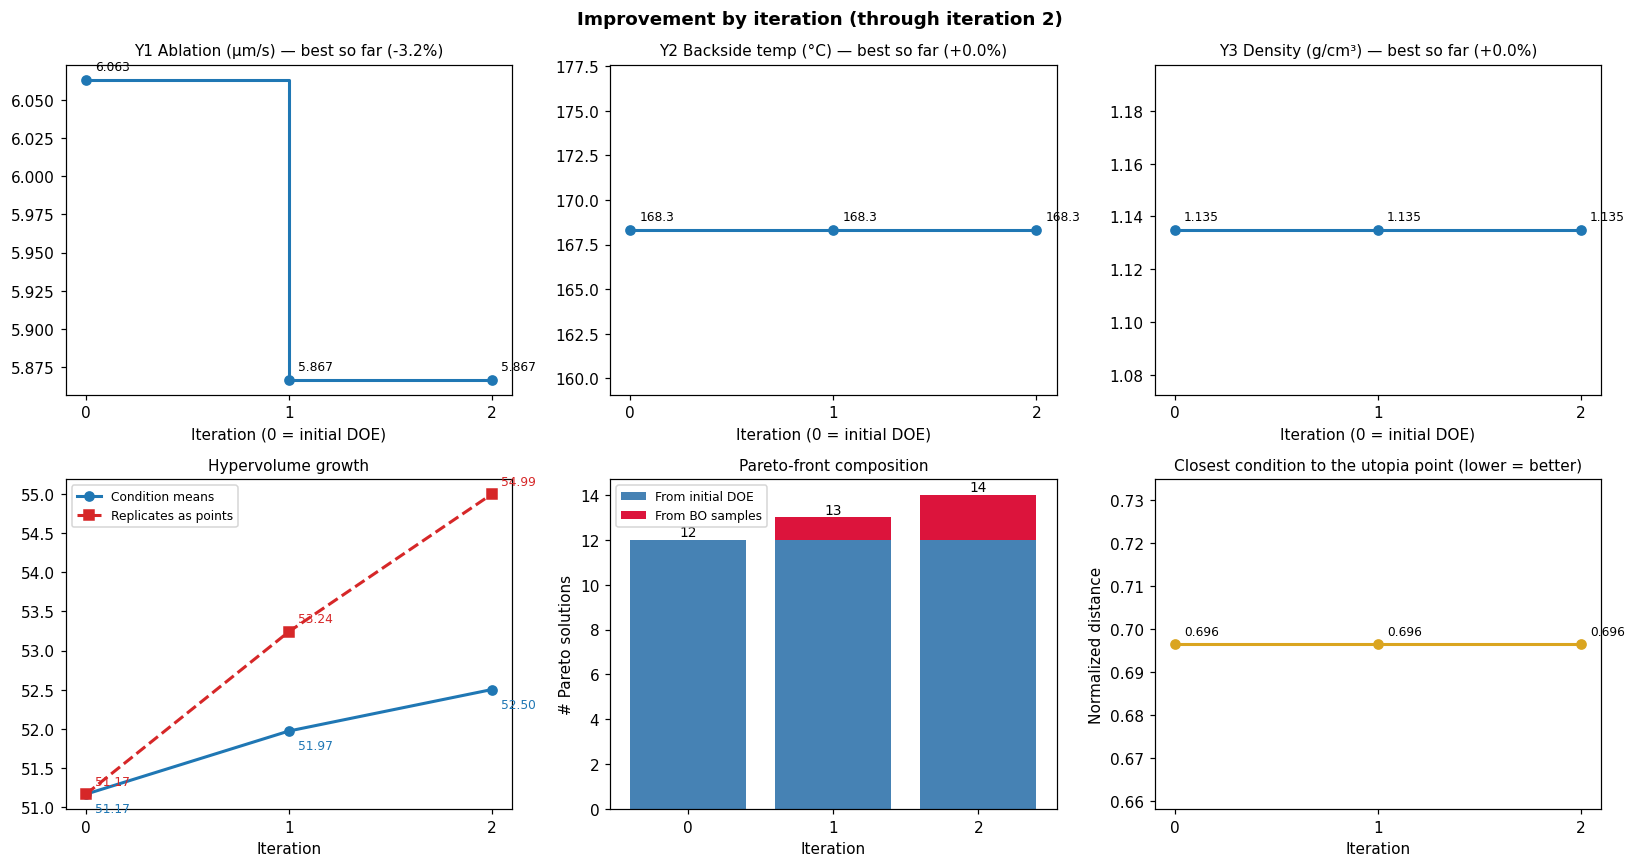

In [27]:
imp_all = camp.improvement(max(camp.tested), full=True)


### 8.4 Where the campaign is exploring
GP surfaces of the model that produced the iteration-3 proposal (data through iteration 2).

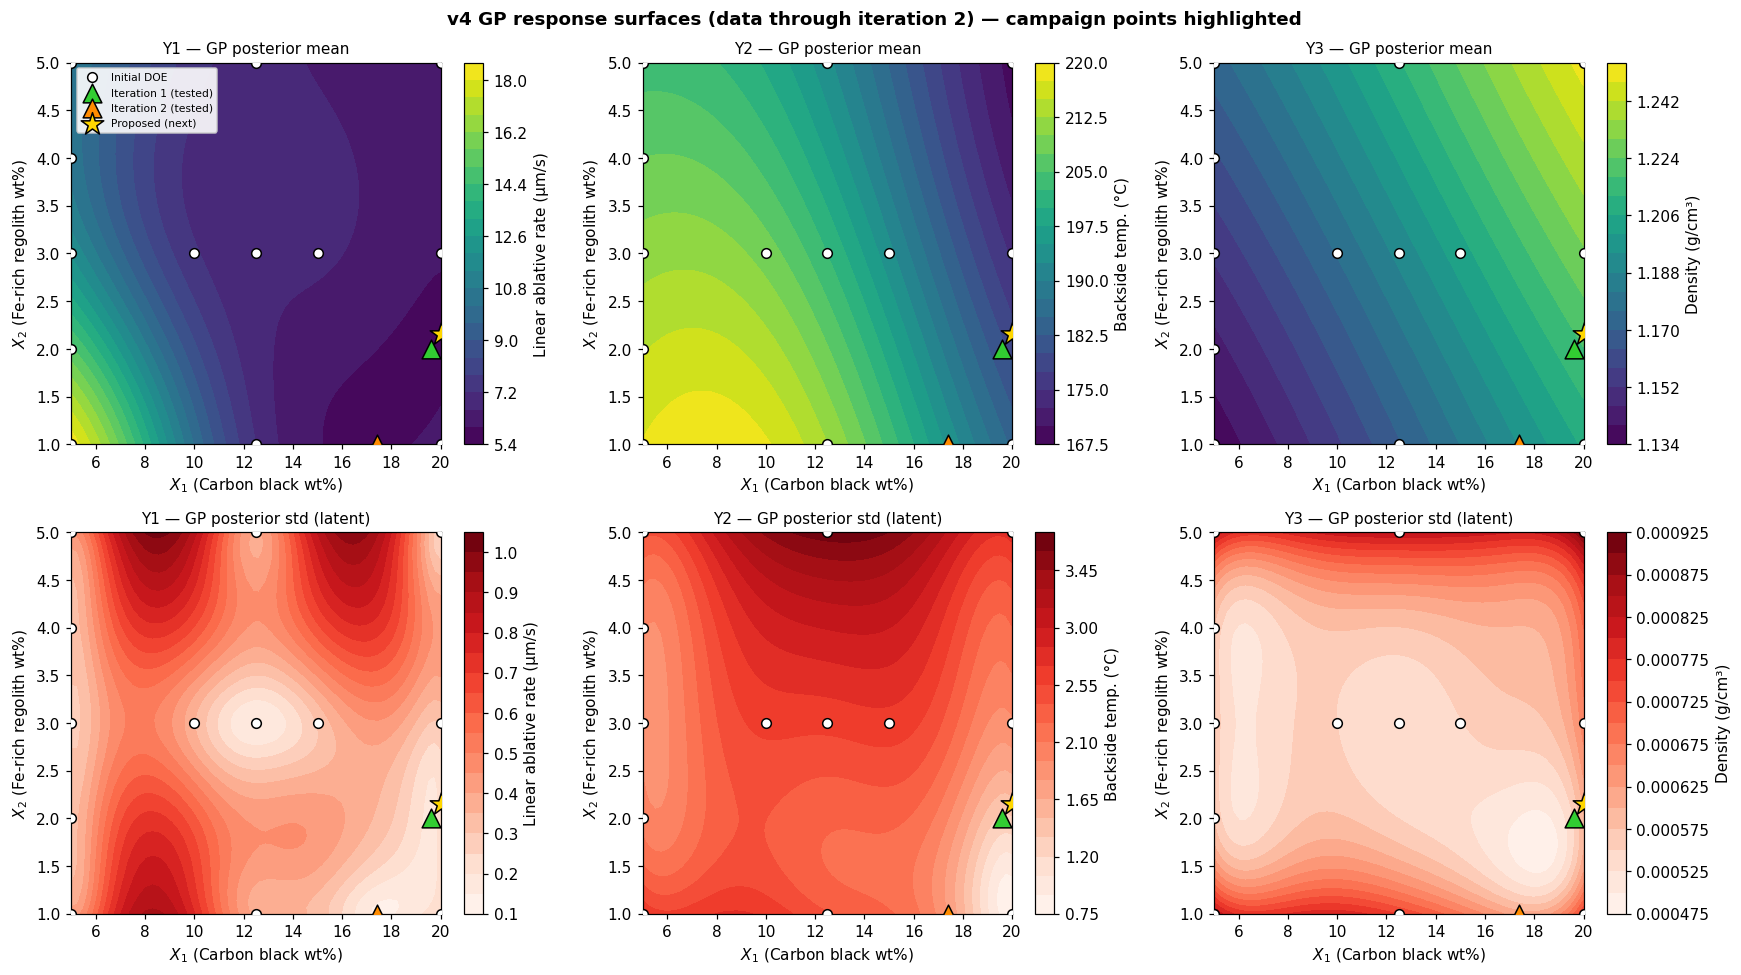

In [28]:
camp.response_surfaces()


## 9. Export
`../outputs/v4/bo_iterations.xlsx` (summary, predictions_v4, predictions_sent, observed,
accuracy, improvement, info), `ablation_data_by_iteration.xlsx` (replicates with
iteration tags and highlighting) and `iteration3_recommended_sample.xlsx` (one-sheet
recommendation for UIC, same layout as the iteration-2 file).

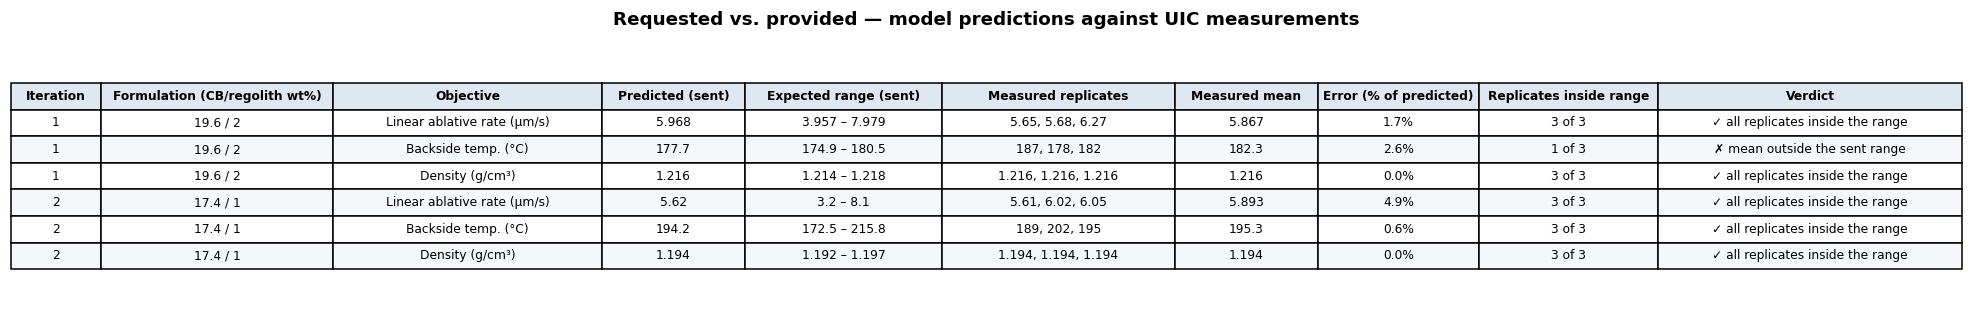

**Recommendation for UIC (iteration 3)**

Component,Carbon black,Fe-rich regolith,I-369,Resin
wt%,20.0,2.2,2.0,75.8


,Predicted mean,Expected range per replicate (95%)
Objective,,
Linear ablative rate (µm/s),5.9200,4.6 – 7.2
Backside temp. (°C),178.4000,157.5 – 199.4
Density (g/cm³),1.2195,1.2172 – 1.2218


wrote ../outputs/v4/bo_iterations.xlsx
wrote ../outputs/v4/ablation_data_by_iteration.xlsx
wrote ../outputs/v4/share/model_performance.xlsx
wrote ../outputs/v4/share/model_performance_table.png
wrote ../outputs/v4/iteration3_recommended_sample.xlsx


In [29]:
paths = camp.export()


## 10. Summary

In [30]:
camp.summary()


CAMPAIGN STATUS — 2 tested iteration(s), iteration 3 pending

Requested → received:
  iter 1: requested (19.58, 1.99) → fabricated 19.6/2; observed means Y1 5.867 (v4 µ 5.976), Y2 182.3 (v4 µ 179.2), Y3 1.216 (v4 µ 1.216); HV after 51.974
  iter 2: requested (17.35, 1.00) → fabricated 17.4/1; observed means Y1 5.893 (v4 µ 5.62), Y2 195.3 (v4 µ 194.2), Y3 1.194 (v4 µ 1.194); HV after 52.503

Next request (iteration 3): X1 = 20.000, X2 = 2.156 → 20 / 2.2  (qLogEHVI -0.4413)
  predicted: Y1 5.918 PI [4.63, 7.206] | Y2 178.4 PI [157.5, 199.4] | Y3 1.22 PI [1.217, 1.222]

Stopping rule before iteration 3 (Wilson 2024, one-step HV regret; ε = 1% of HV, δ = 0.05): P̂(regret ≤ ε) = 0.094 vs λ = 0.975 → CONTINUE
  expected best one-step gain 0.935 HV units (1.78% of HV); front coverage 91.9%; ε=0.5%: CONTINUE; ε=1%: CONTINUE; ε=2%: CONTINUE; ε=5%: STOP; ε=10%: STOP

Improvement vs. the initial DOE (best condition mean):
  Y1 Ablation (µm/s): 6.063 → 5.867 (-3.24%)
  Y2 Backside temp (°C): 168.3